# Capstone Project Genomic Data Analysis:

Nama : Al Hadi Busra

## Introduction

### Latar Belakang Analisis

Pasien didiagnosis dengan *Non-small cell lung carcinoma* (NSCLC) berdasarkan pemeriksaan klinis dan hasil pencitraan. Untuk mengevaluasi apakah pasien memenuhi syarat untuk terapi yang menargetkan EGFR, analisis mutasi dilakukan menggunakan *targeted sequencing* beberapa gen terkait kanker yang terletak pada kromosom 1 dan 7.

Dua sampel dikumpulkan: jaringan tumor dari paru-paru dan sampel darah tepi, dengan sampel darah digunakan sebagai kontrol normal. DNA genomik dari kedua sampel di-*sequencing* menggunakan platform Illumina HiSeq 2000 dengan persiapan *library* menggunakan Illumina TruSeq DNA Library Prep v3 (TruSeq3-SE).

### Tujuan Analisis

Tujuan utama dari analisis data *next-generation sequencing* (NGS) ini adalah untuk menginterpretasikan data *sequencing* dan menentukan apakah pasien merupakan kandidat yang cocok untuk terapi anti-EGFR. Secara spesifik, analisis ini akan melibatkan:

1.  **Deteksi Mutasi Somatik**: Mengidentifikasi mutasi genetik yang spesifik pada jaringan tumor (terutama pada gen EGFR dan gen terkait kanker lainnya di kromosom 1 dan 7) dengan membandingkannya terhadap sampel normal.
2.  **Korelasi Klinis**: Menilai signifikansi klinis dari mutasi yang terdeteksi, khususnya mutasi pada gen EGFR, yang dapat menjadi target terapi.
3.  **Rekomendasi Terapi**: Berdasarkan hasil deteksi mutasi, memberikan rekomendasi apakah pasien dapat menerima terapi anti-EGFR.

## Prepare Working Directories

Sebelum memulai analisis data *next-generation sequencing* (NGS), sangat penting untuk menyiapkan struktur direktori kerja yang terorganisir. Ini akan membantu dalam mengelola *input* dan *output* dari setiap langkah, memudahkan navigasi, dan menjaga alur kerja tetap rapi. Direktori-direktori ini akan digunakan untuk menyimpan data mentah, hasil *quality control*, *reads* yang sudah di-*trim*, *reference genome*, file *alignment*, file *post-alignment*, varian, dan hasil anotasi.

In [ ]:
!
mkdir -p ~/capstone-project/{raw-data,qc,trimmed,reference,alignment,post-alignment,variants,annotation}

### Penjelasan Perintah `mkdir -p`

Perintah `mkdir -p` digunakan untuk membuat satu atau lebih direktori. Berikut rinciannya:

*   `mkdir`: Perintah standar untuk membuat direktori.
*   `-p`: Opsi ini memastikan bahwa setiap direktori induk yang diperlukan akan dibuat jika belum ada. Ini sangat berguna untuk membuat struktur direktori bertingkat.
*   `~/capstone-project/{raw-data,qc,trimmed,reference,alignment,post-alignment,variants,annotation}`: Ini adalah daftar direktori yang akan dibuat di dalam folder `capstone-project` yang berada di direktori home (`~`). Kurung kurawal `{}` digunakan untuk membuat beberapa direktori sekaligus dengan awalan yang sama.

## Download Sample Data

Untuk memulai analisis, kita perlu mengunduh data sampel yang akan digunakan. Data ini akan diambil dari repositori GitHub menggunakan perintah `git clone` dan disimpan di direktori `raw-data` yang sudah disiapkan sebelumnya.

In [ ]:
!git clone https://github.com/PathGenDT/capstone-project-dataset-case1.git ~/capstone-project/raw-data/

### Penjelasan Perintah `git clone`

Perintah `git clone` digunakan untuk mengunduh (mengklon) repositori Git dari *remote server* ke direktori lokal Anda. Berikut rinciannya:

*   `git clone`: Perintah dasar untuk mengklon sebuah repositori.
*   `https://github.com/PathGenDT/capstone-project-dataset-case1.git`: Ini adalah URL repositori Git yang akan diunduh. Repositori ini berisi data sampel yang dibutuhkan untuk proyek *capstone*.
*   `~/capstone-project/raw-data/`: Ini adalah direktori tujuan di mana repositori akan diklon. Tanda `~` merujuk ke direktori home pengguna, dan `capstone-project/raw-data/` adalah sub-direktori yang sudah disiapkan sebelumnya untuk menyimpan data mentah.

## Download ClinVar Database

Dalam analisis varian, salah satu langkah awal yang krusial adalah mengunduh dan menggunakan basis data varian genetik seperti **ClinVar**. Basis data ini akan menjadi referensi penting sepanjang tahapan analisis varian, termasuk setelah langkah-langkah pra-pemrosesan data sekuensing (QC, *trimming*, *alignment*, *sorting*, *indexing*, *marking duplicates*, dan BQSR) selesai.

**Apa itu ClinVar?**
ClinVar adalah arsip publik yang berisi informasi mengenai hubungan antara varian genetik dan kondisi kesehatan manusia. Data dalam ClinVar disumbangkan oleh berbagai laboratorium dan klinik di seluruh dunia, mencakup informasi tentang varian, lokasi genomiknya, fenotipe yang terkait, dan interpretasi klinisnya (misalnya, patogenik, benign, atau *variant of uncertain significance* - VUS).

**Mengapa ClinVar penting dalam analisis varian?**

1.  **Anotasi Varian:** ClinVar digunakan untuk menganotasi varian yang ditemukan dalam sampel pasien. Ini membantu dalam mengklasifikasikan apakah suatu varian yang terdeteksi sudah dikenal dan memiliki makna klinis.
2.  **Prioritisasi Varian:** Dengan informasi dari ClinVar, peneliti dan klinisi dapat memprioritaskan varian yang berpotensi patogenik dan mengabaikan varian benign atau yang tidak relevan secara klinis.
3.  **Interpretasi Klinis:** Informasi dari ClinVar adalah referensi penting untuk interpretasi klinis varian, terutama dalam diagnosis penyakit genetik dan penentuan strategi pengobatan.
4.  **Standarisasi:** ClinVar menyediakan kerangka kerja standar untuk berbagi dan menginterpretasikan data varian genetik.

Biasanya, file ClinVar diunduh dalam format VCF (Variant Call Format) yang terkompresi (`.vcf.gz`). Ini akan digunakan bersama dengan *variant caller* seperti GATK HaplotypeCaller untuk membedakan varian yang diketahui dari varian baru, atau untuk anotasi *post-variant calling*.

### Penjelasan Perintah Bash untuk Mengunduh ClinVar Database

Perintah bash berikut digunakan untuk mengunduh basis data ClinVar dari server FTP NCBI. Proses ini merupakan langkah penting dalam menyiapkan data untuk anotasi varian genetik.

```bash
curl -O https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz \
  --output ~/capstone-project/reference/clinvar.vcf.gz
```

Berikut adalah rincian dari setiap bagian perintah:

*   `curl`: Ini adalah alat baris perintah yang digunakan untuk mentransfer data dengan sintaks URL. `curl` mendukung berbagai protokol, termasuk HTTP, HTTPS, FTP, dan lainnya.

*   `-O`: Opsi ini memberitahu `curl` untuk menyimpan file *output* di direktori saat ini dengan nama file yang sama seperti yang ditentukan dalam URL (`clinvar.vcf.gz`).

*   `https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz`: Ini adalah URL sumber dari mana file ClinVar akan diunduh. URL ini menunjuk ke versi terkompresi dari basis data ClinVar (dalam format VCF) yang disesuaikan dengan *reference genome* GRCh38.

*   `--output ~/capstone-project/reference/clinvar.vcf.gz`: Opsi ini, meskipun `-O` sudah digunakan, secara eksplisit menentukan jalur lengkap dan nama file untuk *output*. Ini akan menimpa perilaku `-O` jika ada perbedaan dalam nama file, atau memastikan file disimpan di lokasi yang ditentukan terlepas dari direktori kerja saat ini. Dalam kasus ini, file `clinvar.vcf.gz` akan disimpan di direktori `~/capstone-project/reference/`.

## Prepare ClinVar for Annotation

Setelah file ClinVar berhasil diunduh, langkah selanjutnya adalah menyiapkan file ini agar dapat digunakan secara efisien untuk anotasi varian dalam analisis *downstream*. Proses ini melibatkan beberapa langkah penting:

1.  **Decompress the file:**
    *   File ClinVar yang diunduh biasanya dalam format terkompresi (`.vcf.gz`). Langkah pertama adalah mendekompensinya menjadi format VCF standar (`.vcf`). Ini memungkinkan modifikasi file dan akses data yang lebih mudah.

2.  **Add `chr` prefix to chromosome names:**
    *   Sangat umum dalam bioinformatika bahwa *reference genome* dan alat analisis menggunakan konvensi penamaan kromosom yang berbeda. Beberapa menggunakan prefiks 'chr' (misalnya, `chr1`, `chr2`), sementara yang lain tidak (misalnya, `1`, `2`). Agar file ClinVar kompatibel dengan *reference genome* yang biasanya memiliki prefiks 'chr' (seperti yang sering digunakan oleh GATK), kita perlu menambahkan prefiks 'chr' ke nama kromosom jika belum ada. Ini penting untuk *alignment* dan *variant calling* yang akurat.

3.  **Compress using bgzip:**
    *   Setelah modifikasi (penambahan prefiks 'chr'), file VCF akan dikompresi ulang menggunakan `bgzip`. `bgzip` adalah versi `gzip` yang khusus dirancang untuk mengompresi file teks yang dapat diindeks, seperti VCF. Kompresi ini mengurangi ukuran file secara signifikan dan membuatnya lebih efisien untuk penyimpanan dan transfer.

4.  **Index using tabix:**
    *   Setelah dikompresi dengan `bgzip`, file VCF perlu diindeks menggunakan `tabix`. Indeks `tabix` (`.tbi` file) memungkinkan alat analisis untuk dengan cepat mencari dan mengambil informasi dari bagian spesifik file VCF berdasarkan koordinat genomik, tanpa harus membaca seluruh file. Ini sangat penting untuk efisiensi dalam proses anotasi varian yang melibatkan jutaan posisi genom.

### Penjelasan Perintah Bash untuk Mempersiapkan ClinVar untuk Anotasi

Setelah file ClinVar berhasil diunduh, langkah selanjutnya adalah menyiapkan file ini agar dapat digunakan secara efisien untuk anotasi varian dalam analisis *downstream*. Proses ini melibatkan beberapa langkah penting:

1.  **Decompress the file:** File ClinVar yang diunduh biasanya dalam format terkompresi (`.vcf.gz`). Langkah pertama adalah mendekompensinya menjadi format VCF standar (`.vcf`). Ini memungkinkan modifikasi file dan akses data yang lebih mudah.

2.  **Add `chr` prefix to chromosome names:** Sangat umum dalam bioinformatika bahwa *reference genome* dan alat analisis menggunakan konvensi penamaan kromosom yang berbeda. Beberapa menggunakan prefiks 'chr' (misalnya, `chr1`, `chr2`), sementara yang lain tidak (misalnya, `1`, `2`). Agar file ClinVar kompatibel dengan *reference genome* yang biasanya memiliki prefiks 'chr' (seperti yang sering digunakan oleh GATK), kita perlu menambahkan prefiks 'chr' ke nama kromosom jika belum ada. Ini penting untuk *alignment* dan *variant calling* yang akurat.

3.  **Compress using bgzip:** Setelah modifikasi (penambahan prefiks 'chr'), file VCF akan dikompresi ulang menggunakan `bgzip`. `bgzip` adalah versi `gzip` yang khusus dirancang untuk mengompresi file teks yang dapat diindeks, seperti VCF. Kompresi ini mengurangi ukuran file secara signifikan dan membuatnya lebih efisien untuk penyimpanan dan transfer.

4.  **Index using tabix:** Setelah dikompresi dengan `bgzip`, file VCF perlu diindeks menggunakan `tabix`. Indeks `tabix` (`.tbi` file) memungkinkan alat analisis untuk dengan cepat mencari dan mengambil informasi dari bagian spesifik file VCF berdasarkan koordinat genomik, tanpa harus membaca seluruh file. Ini sangat penting untuk efisiensi dalam proses anotasi varian yang melibatkan jutaan posisi genom.

Berikut adalah rincian dari setiap perintah yang Anda gunakan:

```bash
gunzip ~/capstone-project/reference/clinvar.vcf.gz

awk 'BEGIN{OFS="\t"} /^#/ {print; next} {$1="chr"$1; print}' \
  ~/capstone-project/reference/clinvar.vcf > ~/capstone-project/reference/clinvar_chr.vcf

bgzip ~/capstone-project/reference/clinvar_chr.vcf

tabix -p vcf ~/capstone-project/reference/clinvar_chr.vcf.gz
```

*   `gunzip ~/capstone-project/reference/clinvar.vcf.gz`: Perintah ini mendekompilasi file `clinvar.vcf.gz` yang terkompresi menjadi `clinvar.vcf` yang tidak terkompresi.

*   `awk 'BEGIN{OFS="\t"} /^#/ {print; next} {$1="chr"$1; print}' ~/capstone-project/reference/clinvar.vcf > ~/capstone-project/reference/clinvar_chr.vcf`:
    *   `awk`: Adalah alat pemrosesan teks yang kuat.
    *   `BEGIN{OFS="\t"}`: Menentukan pemisah *output field* sebagai tab.
    *   `^# {print; next}`: Baris yang dimulai dengan `#` (komentar/header) akan dicetak apa adanya, dan `awk` akan melompat ke baris berikutnya.
    *   `{$1="chr"$1; print}`: Untuk semua baris data (non-header), ia menambahkan prefiks `chr` ke kolom pertama (yang merupakan nama kromosom) dan kemudian mencetak seluruh baris. Outputnya disimpan ke file baru bernama `clinvar_chr.vcf`.

*   `bgzip ~/capstone-project/reference/clinvar_chr.vcf`: Perintah ini mengompresi file `clinvar_chr.vcf` menggunakan `bgzip`, menghasilkan file `clinvar_chr.vcf.gz` yang dapat diindeks.

*   `tabix -p vcf ~/capstone-project/reference/clinvar_chr.vcf.gz`:
    *   `tabix`: Adalah alat untuk mengindeks file teks terkompresi berbasis daerah.
    *   `-p vcf`: Menentukan bahwa file yang diindeks adalah format VCF. Ini memberi tahu `tabix` bagaimana cara mengurai file untuk membuat indeksnya.
    *   `~/capstone-project/reference/clinvar_chr.vcf.gz`: Adalah file VCF terkompresi yang akan diindeks. Ini akan membuat file indeks (`.tbi`) di direktori yang sama.

## Quality Control (QC)

Quality Control (QC) adalah langkah krusial dalam setiap alur kerja analisis data *next-generation sequencing* (NGS). Tujuannya adalah untuk menilai dan memastikan kualitas data mentah sebelum dilakukan analisis lebih lanjut. Data sekuensing yang buruk dapat menyebabkan hasil yang tidak akurat, interpretasi yang salah, dan membuang sumber daya komputasi dan waktu. Oleh karena itu, QC membantu dalam:

*   **Mengidentifikasi masalah data:** Mendeteksi artefak *sequencing*, kontaminasi, *bias*, atau masalah lain yang mungkin timbul selama proses *library preparation* atau *sequencing*.
*   **Menentukan langkah pra-pemrosesan:** Hasil QC akan memandu keputusan mengenai *trimming adapter*, *filtering reads* berkualitas rendah, atau langkah *preprocessing* lainnya yang diperlukan.
*   **Memastikan keandalan hasil:** Hanya dengan data berkualitas tinggi, kita dapat menghasilkan temuan yang akurat dan dapat direplikasi.

Salah satu alat yang paling umum dan banyak digunakan untuk melakukan QC pada data NGS adalah FastQC.

FastQC adalah alat *stand-alone* yang populer untuk melakukan *Quality Control* (QC) pada *sequencing reads* berthroughput tinggi dari berbagai jenis *sequencing*. FastQC menghasilkan laporan yang merangkum berbagai metrik kualitas, membantu peneliti mengidentifikasi potensi masalah dalam data sebelum melanjutkan ke tahapan analisis berikutnya. Beberapa aspek kunci yang diperiksa oleh FastQC meliputi:

*   **Basic Statistics:** Informasi dasar tentang file *reads*, seperti nama file, jenis *encoding* kualitas, total *sequence*, *sequence length*, dan %GC.
*   **Per Base Sequence Quality:** Menunjukkan kualitas pembacaan pada setiap posisi di seluruh *reads*. Idealnya, kualitas harus tinggi di semua posisi.
*   **Per Sequence Quality Scores:** Mendistribusikan skor kualitas rata-rata di seluruh *reads*. Ini membantu mengidentifikasi jika ada sejumlah besar *reads* dengan kualitas rendah.
*   **Per Base Sequence Content:** Memeriksa komposisi nukleotida (A, T, G, C) pada setiap posisi. Penyimpangan signifikan dapat menunjukkan bias *sequencing*.
*   **Per Sequence GC Content:** Membandingkan distribusi kandungan GC *reads* dengan distribusi teoritis. Perbedaan yang besar bisa mengindikasikan kontaminasi atau bias.
*   **Per Base N Content:** Melaporkan persentase basa 'N' (tidak dapat ditentukan) pada setiap posisi. Peningkatan 'N' menunjukkan kualitas *sequencing* yang buruk.
*   **Sequence Length Distribution:** Menampilkan distribusi panjang *reads*. Penting untuk memeriksa apakah *reads* memiliki panjang yang diharapkan.
*   **Duplication Levels:** Mengestimasi tingkat duplikasi dalam *reads*. Duplikasi tinggi bisa mengindikasikan *over-amplification* atau kontaminasi.
*   **Overrepresented Sequences:** Mengidentifikasi *sequences* yang muncul berulang kali dengan frekuensi tinggi, yang mungkin merupakan adaptor *sequencing* atau kontaminasi lainnya.
*   **Adapter Content:** Memeriksa keberadaan *adapter sequences* yang sering digunakan dalam *library preparation*. *Adapter* ini perlu dipangkas (*trimmed*) sebelum analisis lebih lanjut.

Laporan FastQC memberikan gambaran menyeluruh tentang kualitas data mentah dan merupakan langkah penting pertama dalam alur kerja analisis data NGS untuk memastikan keandalan hasil selanjutnya.

In [ ]:
fastqc ~/capstone-project/raw-data/case1/*.fastq.gz -o ~/capstone-project/qc/fastqc_raw/ -t 4

### Penjelasan Perintah `fastqc`

Perintah `fastqc` digunakan untuk menjalankan analisis kualitas pada file *FASTQ*.

*   `fastqc`: Memanggil program FastQC.
*   `~/capstone-project/raw-data/case1/*.fastq.gz`: Ini adalah *input* untuk FastQC. Tanda `*` adalah *wildcard* yang berarti FastQC akan memproses semua file yang diakhiri dengan `.fastq.gz` di dalam direktori `~/capstone-project/raw-data/`.
*   `-o ~/capstone-project/qc/`: Opsi `-o` menentukan direktori *output* untuk laporan kualitas. Dalam kasus ini, semua laporan FastQC akan disimpan di folder `~/capstone-project/qc/fastqc_raw/`.
*   `-t 4`: Opsi `-t` atau `--threads` menentukan jumlah *thread* atau prosesor yang akan digunakan oleh FastQC. Menggunakan 4 *thread* akan mempercepat proses analisis, terutama jika ada banyak file *input* atau file *input* berukuran besar.

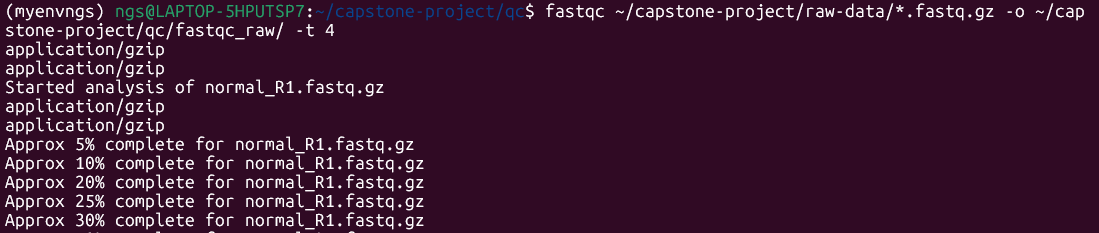

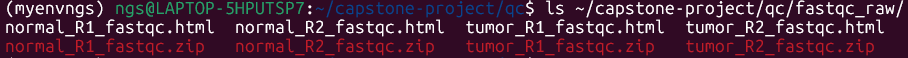

## Trimming

Setelah melakukan *Quality Control* (QC) dan mengidentifikasi potensi masalah pada data *sequencing*, langkah selanjutnya yang sangat penting dalam alur kerja analisis data NGS adalah *trimming*. *Trimming* adalah proses penghilangan bagian *reads* yang berkualitas rendah, *adapter sequences*, atau *contaminant sequences* lainnya yang dapat mengganggu analisis downstream. Tujuan utama dari *trimming* adalah untuk:

*   **Meningkatkan kualitas data:** Menghapus *bases* dengan skor kualitas rendah yang dapat menyebabkan kesalahan dalam *alignment* atau *variant calling*.
*   **Menghilangkan *adapter sequences*:** *Adapter* adalah fragmen DNA pendek yang ditambahkan selama proses *library preparation* untuk tujuan *sequencing*. Jika tidak dihapus, *adapter* ini dapat menutupi *real biological sequences* dan menyebabkan *misalignment*.
*   **Menghapus *contaminant sequences*:** Beberapa *sequences* yang tidak diinginkan (misalnya, dari organisme lain, primer, atau dimmers) dapat muncul dalam data *sequencing* dan perlu dihilangkan.
*   **Mengurangi ukuran data:** Dengan menghapus bagian yang tidak relevan, ukuran file dapat dikurangi, yang mempercepat pemrosesan selanjutnya dan mengurangi kebutuhan sumber daya komputasi.

Proses *trimming* yang efektif memastikan bahwa data yang digunakan untuk analisis selanjutnya adalah bersih, berkualitas tinggi, dan relevan secara biologis. Hal ini sangat penting untuk mendapatkan hasil yang akurat dan dapat diandalkan.

Trimmomatic

Trimmomatic adalah salah satu alat *trimming* yang paling populer dan banyak digunakan untuk data *next-generation sequencing* (NGS). Alat ini didesain untuk menangani berbagai jenis data *sequencing* (misalnya, *single-end* atau *paired-end*) dan menyediakan berbagai opsi *trimming* yang fleksibel. Beberapa fitur utama Trimmomatic meliputi:

*   **Penghapusan *Adapter*:** Trimmomatic dapat secara efisien mendeteksi dan menghapus *adapter sequences* yang sering menjadi masalah pada data NGS.
*   ***Quality Trimming*:** Alat ini dapat memangkas *bases* dari ujung *reads* berdasarkan skor kualitas. Pengguna dapat menentukan ambang batas kualitas minimum atau menggunakan algoritma *sliding window* untuk menentukan daerah berkualitas rendah.
*   ***Leading/Trailing Base Trimming*:** Penghilangan *bases* dari awal (*leading*) atau akhir (*trailing*) *reads* yang memiliki kualitas di bawah ambang batas tertentu.
*   ***Minimum Length Filtering*:** Menghapus *reads* yang menjadi terlalu pendek setelah proses *trimming*, karena *reads* yang sangat pendek mungkin tidak informatif atau sulit untuk di-*align*.
*   **Penanganan *Paired-End Reads*:** Trimmomatic memiliki fungsionalitas khusus untuk *paired-end reads*, memastikan bahwa pasangan *reads* tetap sinkron atau memisahkan *reads* yang pasangannya hilang setelah *trimming*.

Trimmomatic bekerja dengan membaca file *FASTQ*, memproses *reads* sesuai dengan parameter yang ditentukan, dan kemudian menulis *reads* yang sudah dipangkas ke file *FASTQ* output. Pengguna biasanya perlu menyediakan file *adapter* yang berisi *sequences* *adapter* yang akan dihapus. Penggunaan Trimmomatic sangat direkomendasikan untuk pra-pemrosesan data NGS guna memastikan kualitas data yang optimal sebelum analisis lebih lanjut.

**Penjelasan Perintah `trimmomatic`**

Perintah `trimmomatic` yang Anda gunakan berfungsi untuk membersihkan (*trim*) *reads* sekuensing dari *adapter* dan *bases* berkualitas rendah. Berikut rincian dari setiap bagian perintah:

```bash
trimmomatic PE \
  ~/capstone-project/raw-data/case1/case1_normal_R1.fastq.gz \
  ~/capstone-project/raw-data/case1/case1_normal_R2.fastq.gz \
  ~/capstone-project/trimmed/normal_R1_paired.fastq.gz \
  ~/capstone-project/trimmed/normal_R1_unpaired.fastq.gz \
  ~/capstone-project/trimmed/normal_R2_paired.fastq.gz \
  ~/capstone-project/trimmed/normal_R2_unpaired.fastq.gz \
  ILLUMINACLIP:TruSeq3-PE.fa:2:30:10:2:True TAILCROP:36

trimmomatic PE \
  ~/capstone-project/raw-data/case1/case1_tumor_R1.fastq.gz \
  ~/capstone-project/raw-data/case1/case1_tumor_R2.fastq.gz \
  ~/capstone-project/trimmed/tumor_R1_paired.fastq.gz \
  ~/capstone-project/trimmed/tumor_R1_unpaired.fastq.gz \
  ~/capstone-project/trimmed/tumor_R2_paired.fastq.gz \
  ~/capstone-project/trimmed/tumor_R2_unpaired.fastq.gz \
  ILLUMINACLIP:TruSeq3-PE.fa:2:30:10:2:True TAILCROP:36
```

*   `trimmomatic PE`: Memanggil program Trimmomatic dan menentukan bahwa *input* adalah *Paired-End* (`PE`) *reads*.

*   `~/capstone-project/raw-data/case1/case1_normal_R1.fastq.gz ~/capstone-project/raw-data/case1/case1_normal_R2.fastq.gz`: Ini adalah file *input* *Paired-End* untuk sampel normal (Forward dan Reverse). Untuk sampel tumor, akan ada `case1_tumor_R1.fastq.gz` dan `case1_tumor_R2.fastq.gz`.

*   `~/capstone-project/trimmed/normal_R1_paired.fastq.gz`: File *output* untuk *reads* R1 (Forward) yang berhasil berpasangan setelah *trimming*.

*   `~/capstone-project/trimmed/normal_R1_unpaired.fastq.gz`: File *output* untuk *reads* R1 (Forward) yang tidak lagi memiliki pasangannya setelah *trimming* (misalnya, pasangannya terlalu pendek atau hilang).

*   `~/capstone-project/trimmed/normal_R2_paired.fastq.gz`: File *output* untuk *reads* R2 (Reverse) yang berhasil berpasangan setelah *trimming*.

*   `~/capstone-project/trimmed/normal_R2_unpaired.fastq.gz`: File *output* untuk *reads* R2 (Reverse) yang tidak lagi memiliki pasangannya setelah *trimming*.

Berikut adalah penjelasan untuk opsi-opsi *trimming* yang digunakan:

*   `ILLUMINACLIP:TruSeq3-PE.fa:2:30:10:2:True`:
    *   `ILLUMINACLIP`: Digunakan untuk menghapus *adapter sequences*.
    *   `TruSeq3-PE.fa`: File FASTA yang berisi *sequences adapter* yang akan dicari dan dihapus. *TruSeq3-PE.fa* biasanya digunakan untuk *library* yang disiapkan dengan kit TruSeq.
    *   `2`: *Seed mismatches* maksimum yang diizinkan agar *adapter* dapat dikenali.
    *   `30`: *Threshold* *palindromic clip*. *Adapter* akan dipangkas jika cocok dengan *read* secara *palindromic* dengan skor *alignment* 30.
    *   `10`: *Threshold simple clip*. *Adapter* akan dipangkas jika cocok dengan *read* secara *simple* dengan skor *alignment* 10.
    *   `2`: *Min adapter length*. Panjang minimum *adapter* yang harus cocok untuk dihapus.
    *   `True`: Mengaktifkan *clipping* otomatis untuk *adapter* tersembunyi.

*   `TAILCROP:36`: Memangkas *reads* dari ujung 3' (akhir) hingga *reads* memiliki panjang minimum 36 *bases*. Jika *read* menjadi lebih pendek dari 36 *bases* setelah pemangkasan, *read* tersebut akan dibuang.

## Quality Control (QC) After Trimming

Setelah proses *trimming* selesai, sangat penting untuk melakukan tahap *Quality Control* (QC) ulang. QC setelah *trimming* bertujuan untuk memverifikasi bahwa *reads* yang telah "dibersihkan" sekarang benar-benar bebas dari *adapter*, *bases* berkualitas rendah, atau *contaminant sequences* lainnya yang mungkin tidak sepenuhnya terhapus.

Mengapa QC Setelah Trimming Penting?

1.  **Validasi Efektivitas Trimming**: Memastikan bahwa *adapter sequences* dan *bases* berkualitas rendah telah berhasil dihilangkan dari data.
2.  **Mengevaluasi Kualitas Akhir Data**: Memeriksa distribusi panjang *reads* yang baru, komposisi basa, dan profil kualitas setelah *trimming*. Ini penting untuk mengetahui apakah *reads* yang tersisa sudah sesuai standar untuk *alignment* dan analisis *downstream* lainnya.
3.  **Mendeteksi Masalah yang Tersisa**: Terkadang, meskipun *trimming* telah dilakukan, masih ada masalah kualitas tersembunyi atau *bias* yang perlu diidentifikasi sebelum melangkah ke tahap *alignment*.
4.  **Membuat Keputusan Lanjut**: Hasil QC ulang ini dapat memandu keputusan apakah perlu dilakukan *trimming* tambahan dengan parameter yang berbeda, atau apakah data sudah siap untuk tahap *alignment*.

Alat seperti **FastQC** dapat digunakan kembali pada *reads* yang sudah di-*trim* untuk menghasilkan laporan kualitas yang baru. Perbandingan laporan FastQC sebelum dan sesudah *trimming* akan memberikan gambaran jelas tentang peningkatan kualitas data.

**Penjelasan Perintah `fastqc` (QC After Trimming)**

Perintah `fastqc` ini digunakan untuk menjalankan analisis kualitas pada *reads* yang sudah di-*trim*, khususnya yang berpasangan (*paired-end*).

```bash
fastqc ~/capstone-project/trimmed/*_paired.fastq.gz -o ~/capstone-project/qc/fastqc_trimmed/ -t 4
```

Berikut rincian dari setiap bagian perintah:

*   `fastqc`: Memanggil program FastQC.

*   `~/capstone-project/trimmed/*_paired.fastq.gz`: Ini adalah *input* untuk FastQC. Tanda `*` adalah *wildcard* yang berarti FastQC akan memproses semua file yang berakhiran `_paired.fastq.gz` di dalam direktori `~/capstone-project/trimmed/`. Ini memastikan bahwa laporan QC dihasilkan untuk semua *reads* *paired-end* yang telah berhasil di-*trim* dari kedua sampel (normal dan tumor).

*   `-o ~/capstone-project/qc/fastqc_trimmed/`: Opsi `-o` menentukan direktori *output* untuk laporan kualitas. Dalam kasus ini, semua laporan FastQC yang baru akan disimpan di folder `~/capstone-project/qc/fastqc_trimmed/`.

*   `-t 4`: Opsi `-t` atau `--threads` menentukan jumlah *thread* atau prosesor yang akan digunakan oleh FastQC. Menggunakan 4 *thread* akan mempercepat proses analisis, terutama jika ada banyak file *input* atau file *input* berukuran besar.

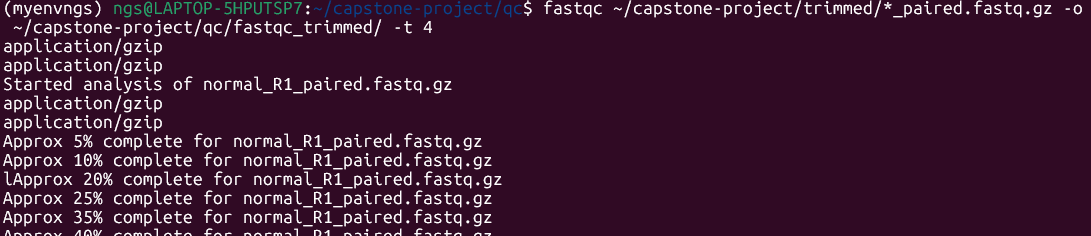

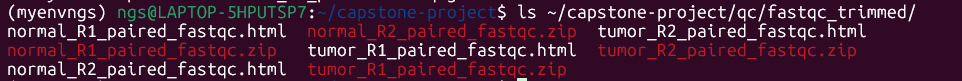

## Alignment

Setelah tahap *Quality Control* (QC) dan *trimming* selesai, langkah selanjutnya dalam alur kerja analisis data NGS adalah *alignment* atau pemetaan *reads*. *Alignment* adalah proses mencocokkan *reads* sekuens pendek yang dihasilkan dari *sequencing* ke *reference genome* yang diketahui. Tujuannya adalah untuk menentukan dari mana setiap *read* berasal di dalam *genome* referensi.

Beberapa alasan mengapa *alignment* sangat penting:

*   **Penentuan Lokasi Genetik:** *Alignment* memungkinkan kita untuk mengetahui lokasi pasti setiap *read* pada *reference genome*, yang merupakan dasar untuk analisis downstream seperti *variant calling*, ekspresi gen, atau identifikasi struktur genetik.
*   **Deteksi Variasi:** Dengan membandingkan *reads* yang ter-*align* dengan *reference genome*, kita dapat mengidentifikasi perbedaan nukleotida (mutasi, SNP, indel) yang mungkin ada pada sampel biologis yang dianalisis.
*   **Kuantifikasi:** Dalam analisis ekspresi gen (RNA-Seq), *alignment* digunakan untuk menghitung berapa banyak *reads* yang memetakan ke setiap gen, memberikan gambaran tentang tingkat ekspresi gen tersebut.
*   **Identifikasi Struktur:** *Alignment* juga dapat membantu dalam mendeteksi perubahan struktural besar seperti duplikasi, delesi, atau translokasi kromosom.

Proses *alignment* biasanya dilakukan menggunakan algoritma khusus yang dirancang untuk secara efisien memetakan jutaan hingga miliaran *reads* ke *genome* yang seringkali sangat besar, sambil memperhitungkan kemungkinan *mismatches* atau *gaps* yang diizinkan.

Burrows-Wheeler Aligner (BWA) adalah salah satu perangkat lunak *alignment* yang paling populer dan banyak digunakan dalam bioinformatika, khususnya untuk memetakan *sequencing reads* pendek ke *reference genome* yang besar. BWA menggunakan algoritma transformasi Burrows-Wheeler (BWT) yang memungkinkan pemetaan *reads* dengan cepat dan efisien.

Ada beberapa mode atau algoritma utama dalam BWA:

*   **BWA-backtrack (BWA aln/sampe):** Dirancang untuk *reads* Illumina yang lebih pendek (hingga ~100 bp). Algoritma ini mencari *seed matches* dan kemudian memperluasnya.
*   **BWA-MEM (BWA mem):** Ini adalah algoritma yang paling direkomendasikan untuk *reads* yang lebih panjang (misalnya, 70 bp atau lebih) dan juga dapat menangani *reads* yang lebih pendek. BWA-MEM lebih cepat dan lebih akurat untuk data modern, terutama *paired-end reads* dan *reads* dengan *gaps*. Ini juga mampu mendeteksi *split reads* dan *chimeric alignments*.
*   **BWA-SW (BWA sw):** Dirancang untuk *reads* yang sangat panjang (misalnya, >10,000 bp) atau *reads* dengan tingkat kesalahan yang tinggi.

Fitur-fitur utama BWA meliputi:

*   **Kecepatan dan Efisiensi:** BWA dikenal karena kemampuannya untuk meng-*align* sejumlah besar *reads* dengan cepat.
*   **Akurasi Tinggi:** BWA mencapai akurasi *alignment* yang baik, bahkan untuk *reads* dengan variasi atau kesalahan sekuensing.
*   **Dukungan untuk *Paired-End Reads*:** BWA dapat memanfaatkan informasi *paired-end* untuk meningkatkan akurasi *alignment* dan mendeteksi *insertions* atau *deletions* besar.
*   **Output Standar (SAM/BAM):** Hasil *alignment* BWA dikeluarkan dalam format SAM (Sequence Alignment/Map) atau BAM (versi biner dari SAM), yang merupakan format standar dalam bioinformatika dan dapat dengan mudah digunakan oleh alat downstream lainnya.

Penggunaan BWA umumnya melibatkan dua langkah utama: pertama, membangun indeks dari *reference genome* (menggunakan `bwa index`), dan kedua, melakukan *alignment* *reads* ke indeks tersebut (menggunakan `bwa mem` atau `bwa aln`).

**Penjelasan Perintah `bwa mem`**

Perintah `bwa mem` adalah salah satu algoritma *alignment* yang paling direkomendasikan dalam BWA untuk memetakan *reads* ke *reference genome*. Berikut adalah rincian dari setiap bagian perintah yang Anda gunakan untuk sampel normal dan tumor:

```bash
bwa mem -t 4 \
  -R '@RG\tID:a1\tSM:normal\tPL:ILLUMINA\tLB:lib1\tPU:f_1' \
  ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  ~/capstone-project/trimmed/normal_R1_paired.fastq.gz \
  ~/capstone-project/trimmed/normal_R2_paired.fastq.gz \
  > ~/capstone-project/alignment/normal.sam

bwa mem -t 4 \
  -R '@RG\tID:a2\tSM:tumor\tPL:ILLUMINA\tLB:lib1\tPU:f_1' \
  ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  ~/capstone-project/trimmed/tumor_R1_paired.fastq.gz \
  ~/capstone-project/trimmed/tumor_R2_paired.fastq.gz \
  > ~/capstone-project/alignment/tumor.sam
```

*   `bwa mem`: Memanggil algoritma BWA-MEM, yang cocok untuk *reads* yang lebih panjang dan *paired-end reads*.

*   `-t 4`: Opsi ini menentukan jumlah *thread* (CPU core) yang akan digunakan oleh BWA-MEM. Menggunakan 4 *thread* akan mempercepat proses *alignment* secara signifikan.

*   `-R '@RG\tID:a1\tSM:normal\tPL:ILLUMINA\tLB:lib1\tPU:f_1'`: Ini adalah argumen *Read Group* (RG) yang penting untuk menambahkan metadata ke file SAM/BAM *output*. Metadata ini membantu mengidentifikasi asal *reads* dan penting untuk analisis *downstream* seperti *variant calling*.
    *   `@RG`: Menandakan ini adalah *read group header*.
    *   `ID:a1` (atau `ID:a2` untuk tumor): *Read Group Identifier*. ID unik untuk *read group* ini.
    *   `SM:normal` (atau `SM:tumor` untuk tumor): *Sample Name*. Nama sampel biologis.
    *   `PL:ILLUMINA`: *Platform*. Nama platform *sequencing* (misalnya, Illumina, PacBio).
    *   `LB:lib1`: *Library*. Nama *library* *sequencing*.
    *   `PU:f_1`: *Platform Unit*. Unit platform yang unik.

*   `~/capstone-project/reference/Homo_sapiens_assembly38.fasta`: Ini adalah jalur ke file *reference genome* dalam format FASTA. BWA akan memetakan *reads* ke *genome* referensi ini. Pastikan *reference genome* ini sudah diindeks oleh BWA sebelumnya (biasanya dengan `bwa index`).

*   `~/capstone-project/trimmed/normal_R1_paired.fastq.gz` dan `~/capstone-project/trimmed/normal_R2_paired.fastq.gz`: Ini adalah file *input* *paired-end reads* (R1 dan R2) yang sudah di-*trim* untuk sampel normal. BWA-MEM akan memetakan kedua *reads* dari setiap pasangan secara bersamaan.

*   `~/capstone-project/trimmed/tumor_R1_paired.fastq.gz` dan `~/capstone-project/trimmed/tumor_R2_paired.fastq.gz`: Serupa dengan di atas, ini adalah file *input* *paired-end reads* yang sudah di-*trim* untuk sampel tumor.

*   `> ~/capstone-project/alignment/normal.sam` (atau `> ~/capstone-project/alignment/tumor.sam` untuk tumor): Ini adalah *redirection output*. Hasil *alignment* akan ditulis ke file SAM (Sequence Alignment/Map) yang ditentukan. File SAM ini akan berisi informasi tentang bagaimana setiap *read* dipetakan ke *reference genome*.

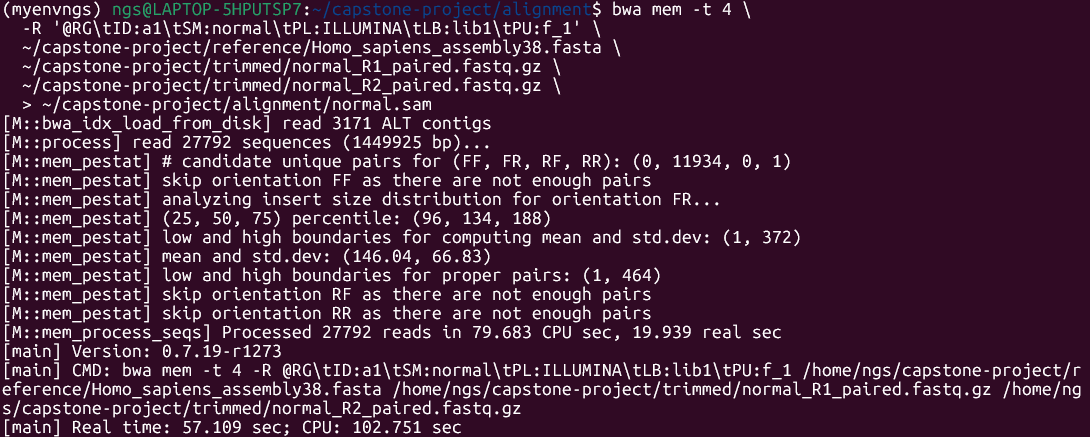

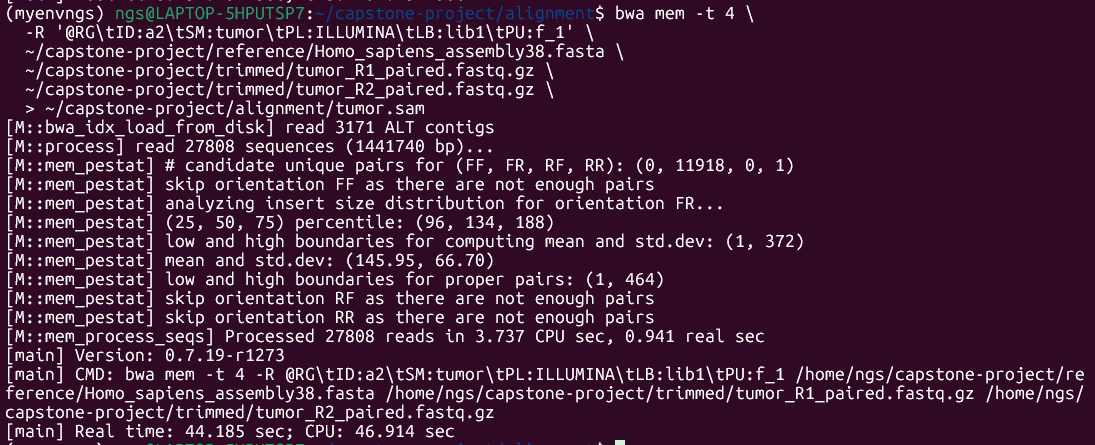

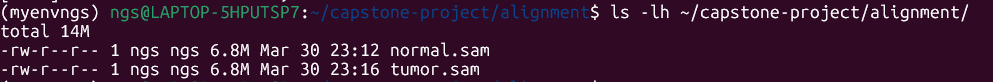

## Konversi SAM ke BAM

Setelah proses *alignment* selesai menggunakan alat seperti BWA, hasil *output* umumnya berupa file dalam format SAM (*Sequence Alignment/Map*). Meskipun format SAM sangat informatif dan mudah dibaca (teks), ukurannya seringkali sangat besar, yang dapat memakan banyak ruang penyimpanan dan memperlambat proses analisis selanjutnya. Oleh karena itu, langkah berikutnya yang penting dalam alur kerja analisis data NGS adalah mengkonversi file SAM ke format BAM (*Binary Alignment/Map*).

**Perbedaan antara SAM dan BAM:**

*   **SAM:** Format berbasis teks, mudah dibaca manusia, tetapi ukurannya besar.
*   **BAM:** Versi biner dan terkompresi dari SAM, ukurannya jauh lebih kecil, lebih efisien untuk penyimpanan dan pemrosesan komputasi.

**Mengapa konversi SAM ke BAM penting?**

1.  **Efisiensi Penyimpanan:** File BAM dapat berukuran 5-10 kali lebih kecil dari file SAM yang setara, menghemat ruang penyimpanan yang signifikan.
2.  **Kecepatan Pemrosesan:** Karena ukurannya yang lebih kecil, file BAM dapat dimuat dan diproses lebih cepat oleh berbagai alat bioinformatika *downstream*, seperti untuk *variant calling* (misalnya, GATK, samtools) atau visualisasi (*genome browser* seperti IGV).
3.  **Pengindeksan (Indexing):** File BAM dapat diindeks (misalnya, dengan membuat file `.bai`), yang memungkinkan akses cepat ke *reads* di lokasi genom tertentu tanpa perlu membaca seluruh file. Ini sangat penting untuk navigasi dan analisis efisien.

**Alat Umum untuk Konversi:**

Alat yang paling umum digunakan untuk mengkonversi SAM ke BAM (dan sebaliknya) adalah **Samtools**. Samtools adalah *suite* program yang kuat untuk memanipulasi data *alignment* dalam format SAM, BAM, dan CRAM. Proses konversi dasar dengan Samtools melibatkan perintah:

```bash
samtools view -bS input.sam > output.bam
```

Di mana:
*   `-b`: Menentukan *output* dalam format BAM.
*   `-S`: Menunjukkan bahwa *input* adalah file SAM (secara *default*, Samtools mengharapkan *input* BAM, jadi `-S` diperlukan jika *input* adalah SAM).
*   `input.sam`: File *input* SAM.
*   `output.bam`: File *output* BAM yang dihasilkan.

Selain itu, Samtools juga dapat digunakan untuk mengurutkan file BAM (`samtools sort`) dan membuat indeks (`samtools index`), yang merupakan langkah krusial sebelum melanjutkan ke analisis *variant calling*.

**Penjelasan Perintah `samtools view` (Konversi SAM ke BAM)**

Perintah `samtools view` digunakan untuk melihat, memfilter, dan mengkonversi file *alignment* dari format SAM ke BAM. Berikut adalah rincian dari setiap argumen yang Anda gunakan untuk kedua sampel (normal dan tumor):

```bash
samtools view -Shb \
  -o ~/capstone-project/post-alignment/bam/normal.bam \
  ~/capstone-project/alignment/normal.sam

samtools view -Shb \
  -o ~/capstone-project/post-alignment/bam/tumor.bam \
  ~/capstone-project/alignment/tumor.sam
```

*   `samtools view`: Memanggil alat `view` dari **Samtools**.

*   `-S`: Opsi ini menunjukkan bahwa file *input* yang diberikan adalah dalam format **SAM** (teks). Samtools secara *default* menganggap *input* adalah BAM, sehingga `-S` diperlukan jika Anda memulai dari SAM.

*   `-h`: Opsi ini memastikan bahwa *header* dari file SAM *input* akan disertakan dalam *output* BAM. *Header* mengandung informasi penting tentang *reference genome* dan *read group*.

*   `-b`: Opsi ini menentukan bahwa *output* yang dihasilkan harus dalam format **BAM** (biner dan terkompresi).

*   `-o ~/capstone-project/post-alignment/bam/normal.bam` (atau `tumor.bam`): Menentukan jalur dan nama file *output* BAM. File BAM yang sudah dikonversi akan disimpan di direktori `~/capstone-project/post-alignment/bam/` dengan nama yang sesuai (misalnya, `normal.bam` atau `tumor.bam`).

*   `~/capstone-project/alignment/normal.sam` (atau `tumor.sam`): Menentukan jalur ke file SAM *input*. Ini adalah file hasil *alignment* dari BWA untuk sampel normal atau tumor.

Proses ini mengubah file *alignment* SAM yang berukuran besar menjadi file BAM yang lebih kecil dan efisien, yang siap untuk langkah *post-alignment* selanjutnya seperti pengurutan dan pengindeksan.

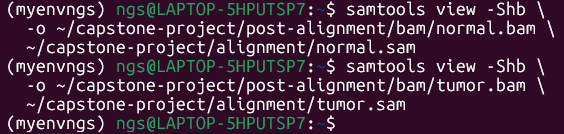

## Sort BAM

Setelah file *alignment* dikonversi dari SAM ke BAM, langkah penting berikutnya adalah mengurutkan file BAM tersebut. Pengurutan file BAM adalah proses mengatur *reads* dalam file berdasarkan koordinat posisi mereka pada *reference genome*. Ini adalah langkah *preprocessing* yang sangat krusial untuk banyak alat analisis *downstream*.

**Mengapa pengurutan file BAM penting?**

1.  **Dibutuhkan untuk Pengindeksan (Indexing):** Sebagian besar alat *variant calling* dan *genome browser* memerlukan file BAM yang sudah diurutkan dan diindeks. Indeks BAM (file `.bai`) memungkinkan akses cepat ke *reads* di bagian tertentu dari *genome* tanpa harus membaca seluruh file secara berurutan. File BAM harus diurutkan sebelum dapat diindeks.
2.  **Meningkatkan Efisiensi Alat *Downstream*:** Banyak algoritma dalam alat analisis *downstream* (misalnya, untuk *variant calling*, *mutation calling*, atau *copy number variation*) dirancang untuk bekerja secara efisien dengan *reads* yang sudah diurutkan. Pemrosesan *reads* secara sekuensial berdasarkan posisi genomik akan mengurangi waktu komputasi dan penggunaan memori.
3.  **Memudahkan Pembacaan oleh *Genome Browser*:** Saat memvisualisasikan data *alignment* di *genome browser* seperti IGV (Integrative Genomics Viewer), file BAM yang terurut memungkinkan *browser* untuk memuat dan menampilkan *reads* dengan cepat di wilayah genomik yang diminati.
4.  **Standar dalam Bioinformatika:** Pengurutan file BAM telah menjadi praktik standar dalam alur kerja analisis data NGS untuk memastikan kompatibilitas dan kinerja optimal dengan berbagai alat.

**Alat Umum untuk Pengurutan:**

Alat yang paling umum digunakan untuk mengurutkan file BAM adalah **Samtools**. Perintah dasar untuk mengurutkan file BAM adalah:

```bash
samtools sort input.bam -o sorted_output.bam
```

Di mana:
*   `input.bam`: File BAM yang akan diurutkan.
*   `-o sorted_output.bam`: Nama file BAM yang sudah diurutkan sebagai *output*.

**Penjelasan Perintah `samtools sort` (Pengurutan File BAM)**

Perintah `samtools sort` digunakan untuk mengurutkan file BAM (Binary Alignment/Map) berdasarkan koordinat posisi mereka pada *reference genome*. Ini adalah langkah *preprocessing* yang sangat penting untuk banyak alat analisis *downstream*.

Berikut adalah rincian dari setiap argumen yang Anda gunakan untuk kedua sampel (normal dan tumor):

```bash
samtools sort \
  -o ~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam \
  ~/capstone-project/post-alignment/bam/normal.bam

samtools sort \
  -o ~/capstone-project/post-alignment/sorted-bam/tumor_sorted.bam \
  ~/capstone-project/post-alignment/bam/tumor.bam
```

*   `samtools sort`: Memanggil alat `sort` dari **Samtools**.

*   `-o ~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam` (atau `tumor_sorted.bam`): Menentukan jalur dan nama file *output* BAM yang sudah diurutkan. File ini akan disimpan di direktori `~/capstone-project/post-alignment/sorted-bam/` dengan nama yang sesuai (misalnya, `normal_sorted.bam` atau `tumor_sorted.bam`).

*   `~/capstone-project/post-alignment/bam/normal.bam` (atau `tumor.bam`): Menentukan jalur ke file BAM *input* yang akan diurutkan. Ini adalah file BAM yang dihasilkan dari langkah konversi SAM ke BAM sebelumnya.

Proses pengurutan ini adalah prasyarat untuk banyak alat bioinformatika *downstream*, termasuk pengindeksan file BAM (`samtools index`) dan *variant calling*.

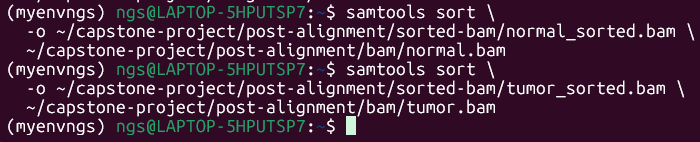

## Index BAM File

Setelah file BAM diurutkan, langkah selanjutnya yang sangat penting adalah membuat indeks untuk file BAM tersebut. Proses ini dikenal sebagai 'Indexing BAM File'. Indeks ini menciptakan file terpisah, biasanya dengan ekstensi `.bai` (BAM Index), yang memungkinkan akses cepat ke *reads* di lokasi spesifik dalam *genome* tanpa perlu membaca seluruh file BAM.

**Mengapa pengindeksan file BAM penting?**

1.  **Akses Cepat ke Data Spesifik:** Indeks memungkinkan alat bioinformatika untuk langsung melompat ke bagian tertentu dari file BAM. Ini sangat krusial untuk analisis yang hanya berfokus pada wilayah *genomic* tertentu, seperti *variant calling* pada gen spesifik atau visualisasi di *genome browser*.
2.  **Dibutuhkan oleh Banyak Alat *Downstream*:** Sebagian besar alat analisis *downstream* dalam alur kerja NGS (misalnya, GATK untuk *variant calling*, IGV untuk visualisasi, samtools faidx untuk mengekstrak sekuens) *membutuhkan* file BAM yang sudah diindeks untuk beroperasi dengan benar dan efisien.
3.  **Mempercepat Visualisasi:** Ketika Anda memuat file BAM di *genome browser* seperti IGV, indeks `.bai` memungkinkan *browser* untuk dengan cepat menampilkan *reads* yang relevan dengan area *genomic* yang sedang Anda lihat, tanpa memuat seluruh file yang mungkin berukuran terabyte.

**Alat Umum untuk Pengindeksan:**

Alat yang paling umum digunakan untuk mengindeks file BAM adalah **Samtools**. File BAM harus diurutkan terlebih dahulu sebelum dapat diindeks.

Perintah dasar untuk mengindeks file BAM adalah:

```bash
samtools index sorted_input.bam
```

Di mana:
*   `sorted_input.bam`: File BAM yang sudah diurutkan. Perintah ini akan membuat file `sorted_input.bam.bai` di direktori yang sama.

**Penjelasan Perintah `samtools index` (Pengindeksan File BAM)**

Perintah `samtools index` digunakan untuk membuat indeks pada file BAM yang sudah diurutkan. Indeks ini penting untuk akses cepat ke data *alignment* di lokasi genomik tertentu.

Berikut adalah rincian dari setiap perintah yang Anda berikan untuk kedua sampel (normal dan tumor):

```bash
samtools index \
  ~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam

samtools index \
  ~/capstone-project/post-alignment/sorted-bam/tumor_sorted.bam
```

*   `samtools index`: Memanggil alat `index` dari **Samtools**.

*   `~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam` (atau `tumor_sorted.bam`): Ini adalah file BAM *input* yang sudah diurutkan. Perintah ini akan membuat file indeks baru dengan ekstensi `.bai` (misalnya, `normal_sorted.bam.bai`) di direktori yang sama dengan file BAM yang diindeks. File `.bai` ini memungkinkan alat *downstream* untuk mengakses *reads* di wilayah *genomic* tertentu dengan cepat dan efisien.

Pengindeksan adalah langkah penting setelah pengurutan, dan merupakan prasyarat untuk sebagian besar alat analisis *downstream* seperti *variant calling* dan visualisasi data.

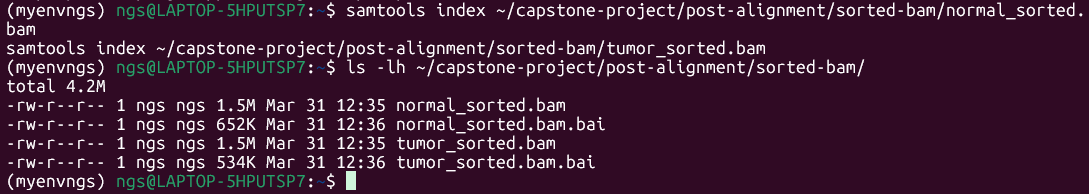

## Mark Duplicate Reads

Setelah proses *alignment*, pengurutan, dan pengindeksan file BAM, langkah selanjutnya yang sangat penting dalam analisis data NGS, terutama untuk aplikasi seperti *variant calling*, adalah 'Mark Duplicate Reads'. Langkah ini mengidentifikasi dan menandai *reads* yang merupakan duplikat. *Reads* duplikat adalah *reads* yang memiliki posisi awal dan orientasi yang sama di *genome* referensi.

**Mengapa menandai *reads* duplikat penting?**

1.  **Sumber Bias:** Duplikasi *reads* dapat terjadi secara artifisial selama proses *library preparation* (misalnya, selama *PCR amplification*) dan bukan merupakan representasi biologis dari jumlah molekul DNA asli. Jika tidak ditangani, *reads* duplikat ini dapat secara artifisial meningkatkan kedalaman liputan (*coverage*) di lokasi tertentu, yang dapat mengarah pada deteksi varian yang salah atau estimasi frekuensi alel yang tidak akurat.
2.  **Meningkatkan Akurasi *Variant Calling*:** Dengan menandai (dan seringkali mengabaikan dalam analisis *downstream*) *reads* duplikat, kita dapat mengurangi *false positives* dalam *variant calling* dan meningkatkan kepercayaan pada varian yang terdeteksi.
3.  **Representasi Data yang Lebih Akurat:** Memastikan bahwa setiap fragmen DNA asli hanya dihitung sekali akan memberikan gambaran yang lebih akurat tentang komposisi *genome* sampel.

**Alat Umum untuk Menandai Duplikat:**

Alat yang paling umum digunakan untuk menandai *reads* duplikat adalah **Picard Tools** (khususnya perintah `MarkDuplicates`) atau **GATK** (sekarang fitur `MarkDuplicates` sudah terintegrasi). Alat-alat ini akan memindai file BAM yang sudah diurutkan, mengidentifikasi *reads* yang diduga duplikat berdasarkan koordinat *mapping*, dan kemudian menandainya dengan flag khusus di header BAM (bit 0x400 pada flag SAM).


**Penjelasan Perintah `gatk MarkDuplicates` (Menandai Duplikat Reads)**

Perintah `gatk MarkDuplicates` digunakan untuk mengidentifikasi dan menandai *reads* duplikat dalam file BAM yang sudah diurutkan. *Reads* duplikat adalah *reads* yang kemungkinan besar berasal dari fragmen DNA yang sama dan seringkali merupakan artefak dari proses *PCR amplification* selama persiapan *library*.

Berikut adalah rincian dari setiap argumen yang Anda gunakan untuk kedua sampel (normal dan tumor):

```bash
gatk MarkDuplicates \
  -I ~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam \
  -O ~/capstone-project/post-alignment/markduplicates/normal_markdup.bam \
  -M ~/capstone-project/post-alignment/markduplicates/normal_markdup_metrics.txt

gatk MarkDuplicates \
  -I ~/capstone-project/post-alignment/sorted-bam/tumor_sorted.bam \
  -O ~/capstone-project/post-alignment/markduplicates/tumor_markdup.bam \
  -M ~/capstone-project/post-alignment/markduplicates/tumor_markdup_metrics.txt
```

*   `gatk MarkDuplicates`: Memanggil alat `MarkDuplicates` dari **GATK**.

*   `-I ~/capstone-project/post-alignment/sorted-bam/normal_sorted.bam` (atau `tumor_sorted.bam`): Menentukan jalur ke file BAM *input* yang sudah diurutkan. Ini adalah file tempat `MarkDuplicates` akan mencari *reads* duplikat.

*   `-O ~/capstone-project/post-alignment/markduplicates/normal_markdup.bam` (atau `tumor_markdup.bam`): Menentukan jalur dan nama file BAM *output*. File ini akan berisi semua *reads* dari file *input*, tetapi *reads* yang diidentifikasi sebagai duplikat akan ditandai dengan *flag* khusus. File ini akan disimpan di direktori `~/capstone-project/post-alignment/markduplicates/`.

*   `-M ~/capstone-project/post-alignment/markduplicates/normal_markdup_metrics.txt` (atau `tumor_markdup_metrics.txt`): Menentukan jalur dan nama file *output* untuk metrik duplikasi. File teks ini akan berisi statistik tentang jumlah *reads* duplikat yang ditemukan.

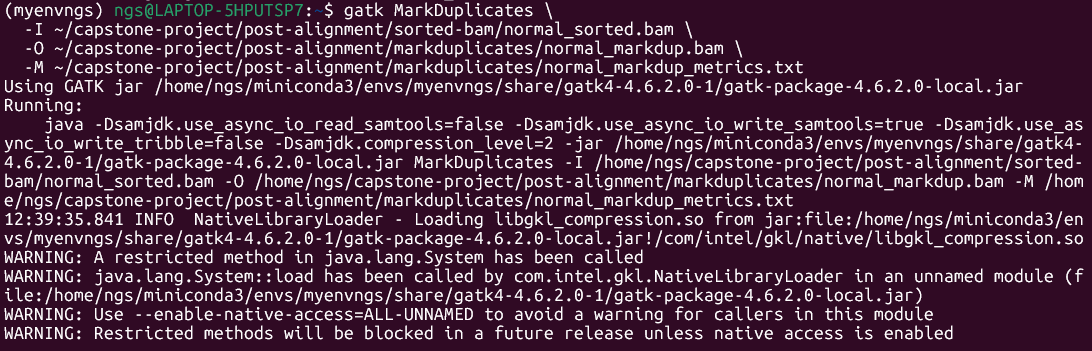

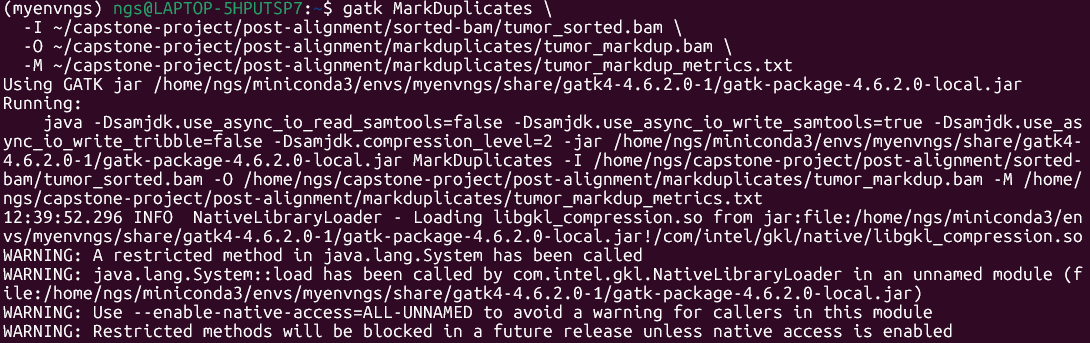

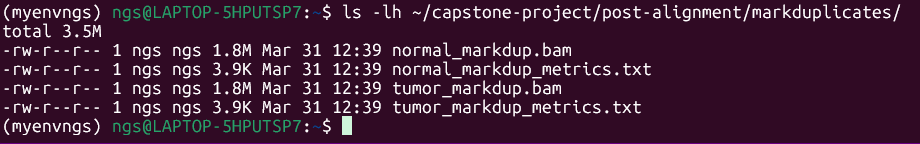

## Base Quality Score Recalibration (BQSR)

Setelah *reads* di-*align*, diurutkan, diindeks, dan duplikat ditandai, langkah selanjutnya yang sangat direkomendasikan sebelum *variant calling* adalah 'Base Quality Score Recalibration' (BQSR). BQSR adalah proses untuk memperbaiki akurasi skor kualitas basa (*base quality scores*) yang dihasilkan oleh mesin *sequencing*.

Skor kualitas basa menunjukkan probabilitas bahwa suatu basa tertentu di-*sequencing* dengan benar. Mesin *sequencing* seringkali memiliki *bias* sistematis yang dapat menyebabkan skor kualitas ini tidak selalu mencerminkan akurasi sebenarnya. Misalnya, basa di akhir *reads* mungkin secara sistematis memiliki skor kualitas yang lebih rendah, atau pola *sequencing* tertentu dapat menyebabkan kesalahan berulang.

**Mengapa BQSR penting?**

1.  **Meningkatkan Akurasi Skor Kualitas:** BQSR menggunakan model statistik untuk memprediksi probabilitas kesalahan basa berdasarkan beberapa kovariat (misalnya, posisi dalam *read*, siklus *sequencing*, konteks basa di sekitarnya). Ini menghasilkan skor kualitas yang lebih akurat dan kalibrasi yang lebih baik.
2.  **Mengurangi *False Positives* dalam *Variant Calling*:** Skor kualitas basa yang tidak akurat dapat menyebabkan deteksi varian yang salah (*false positives*) atau mengabaikan varian yang sebenarnya (*false negatives*). Dengan skor kualitas yang direkalibrasi, *variant caller* dapat membuat keputusan yang lebih tepat tentang apakah suatu penyimpangan dari *reference genome* adalah varian asli atau hanya kesalahan *sequencing*.
3.  **Meningkatkan Sensitivitas dan Spesifisitas:** Rekalibrasi membantu *variant caller* membedakan antara sinyal biologis (varian) dan *noise* (kesalahan *sequencing*), sehingga meningkatkan kinerja keseluruhan dalam mendeteksi varian.

**Alat Umum untuk BQSR:**

Alat yang paling umum dan direkomendasikan untuk melakukan BQSR adalah **GATK** (Genome Analysis Toolkit) dari Broad Institute. Proses BQSR di GATK biasanya melibatkan dua langkah utama:

1.  **`BaseRecalibrator`:** Langkah ini menganalisis pola *mismatch* dalam file BAM yang sudah di-*align* (dengan asumsi *reads* duplikat ditandai dan *indel realignment* telah dilakukan jika diperlukan) terhadap *reference genome* dan kumpulan varian yang diketahui (misalnya, dbSNP). Ini mengumpulkan statistik tentang *bias* skor kualitas.
```bash
gatk BaseRecalibrator \
      -I input.bam \
      -R reference.fa \
      --known-sites known_variants.vcf \
      -O recal_data.table
```

2.  **`ApplyBQSR`:** Langkah ini mengambil file `.table` yang dihasilkan oleh `BaseRecalibrator` dan menerapkannya ke file BAM yang sama untuk menghasilkan file BAM baru dengan skor kualitas basa yang direkalibrasi.
```bash
gatk ApplyBQSR \
      -I input.bam \
      -R reference.fa \
      --bqsr-recal-file recal_data.table \
      -O recalibrated.bam
```

File BAM yang telah direkalibrasi ini kemudian siap untuk proses *variant calling*.

**Penjelasan Perintah BQSR (Base Quality Score Recalibration)**

Proses Base Quality Score Recalibration (BQSR) sangat penting dalam analisis data NGS untuk memperbaiki akurasi skor kualitas basa. Ini melibatkan dua langkah utama menggunakan GATK:

1.  **`BaseRecalibrator`**: Menganalisis pola *mismatch* dalam file BAM terhadap *reference genome* dan kumpulan varian yang diketahui untuk mengumpulkan statistik *bias* skor kualitas.
2.  **`ApplyBQSR`**: Menerapkan koreksi skor kualitas berdasarkan statistik yang dihasilkan oleh `BaseRecalibrator` ke file BAM.

Berikut adalah rincian dari setiap perintah yang Anda gunakan untuk sampel normal dan tumor:

#### Perintah `gatk BaseRecalibrator`

Perintah ini digunakan untuk membangun model rekablibarsi berdasarkan kovariat dari *reads* yang dipetakan.

```bash
gatk BaseRecalibrator \
  -I ~/capstone-project/post-alignment/markduplicates/normal_markdup.bam \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  --known-sites ~/capstone-project/reference/Homo_sapiens_assembly38.known_indels.vcf.gz \
  --known-sites ~/capstone-project/reference/clinvar_chr.vcf.gz \
  -O ~/capstone-project/post-alignment/bqsr/normal_recal.table

gatk BaseRecalibrator \
  -I ~/capstone-project/post-alignment/markduplicates/tumor_markdup.bam \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  --known-sites ~/capstone-project/reference/Homo_sapiens_assembly38.known_indels.vcf.gz \
  --known-sites ~/capstone-project/reference/clinvar_chr.vcf.gz \
  -O ~/capstone-project/post-alignment/bqsr/tumor_recal.table
```

*   `gatk BaseRecalibrator`: Memanggil alat `BaseRecalibrator` dari GATK.
*   `-I <input.bam>`: Menentukan jalur ke file BAM *input* yang sudah ditandai duplikat (`normal_markdup.bam` atau `tumor_markdup.bam`).
*   `-R <reference.fasta>`: Menentukan jalur ke *reference genome* (`Homo_sapiens_assembly38.fasta`) yang digunakan untuk pemetaan.
*   `--known-sites <known_variants.vcf.gz>`: Menyediakan file VCF berisi varian yang sudah diketahui (misalnya, `Homo_sapiens_assembly38.known_indels.vcf.gz` dan `clinvar_chr.vcf.gz`). Ini penting agar `BaseRecalibrator` dapat membedakan *mismatches* yang merupakan varian asli dari *mismatches* yang disebabkan oleh kesalahan *sequencing*.
*   `-O <output.table>`: Menentukan nama file *output* (`normal_recal.table` atau `tumor_recal.table`) yang akan berisi tabel kovariat rekablibarsi.

#### Perintah `gatk ApplyBQSR`

Perintah ini digunakan untuk menerapkan model rekablibarsi yang telah dibuat sebelumnya ke file BAM, menghasilkan file BAM baru dengan skor kualitas basa yang sudah diperbaiki.

```bash
gatk ApplyBQSR \
  -I ~/capstone-project/post-alignment/markduplicates/normal_markdup.bam \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  --bqsr-recal-file ~/capstone-project/post-alignment/bqsr/normal_recal.table \
  -O ~/capstone-project/post-alignment/bqsr/normal_bqsr.bam

gatk ApplyBQSR \
  -I ~/capstone-project/post-alignment/markduplicates/tumor_markdup.bam \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  --bqsr-recal-file ~/capstone-project/post-alignment/bqsr/tumor_recal.table \
  -O ~/capstone-project/post-alignment/bqsr/tumor_bqsr.bam
```

*   `gatk ApplyBQSR`: Memanggil alat `ApplyBQSR` dari GATK.
*   `-I <input.bam>`: Menentukan jalur ke file BAM *input* yang sudah ditandai duplikat (`normal_markdup.bam` atau `tumor_markdup.bam`).
*   `-R <reference.fasta>`: Menentukan jalur ke *reference genome* (`Homo_sapiens_assembly38.fasta`).
*   `--bqsr-recal-file <recal_data.table>`: Menyediakan file tabel rekablibarsi (`normal_recal.table` atau `tumor_recal.table`) yang dihasilkan oleh `BaseRecalibrator`.
*   `-O <output.bam>`: Menentukan nama file BAM *output* (`normal_bqsr.bam` atau `tumor_bqsr.bam`) yang akan berisi *reads* dengan skor kualitas basa yang sudah direkalibrasi.

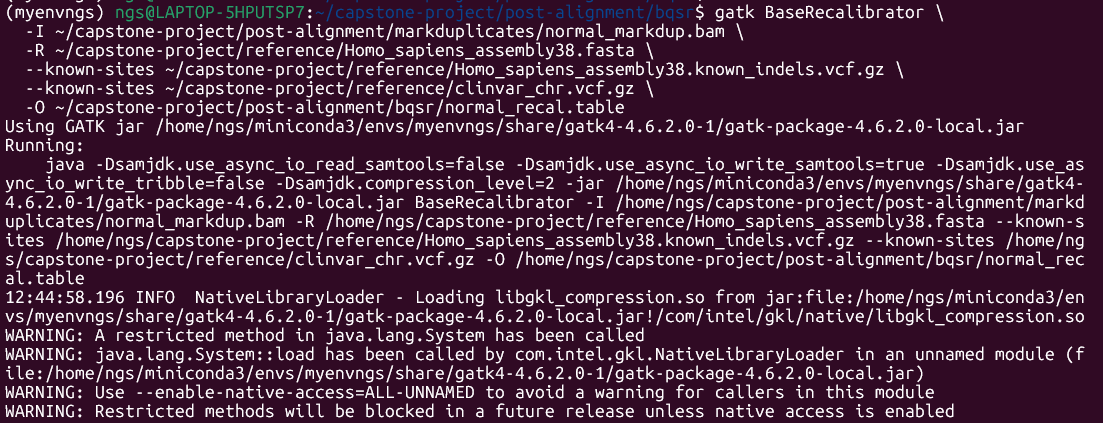

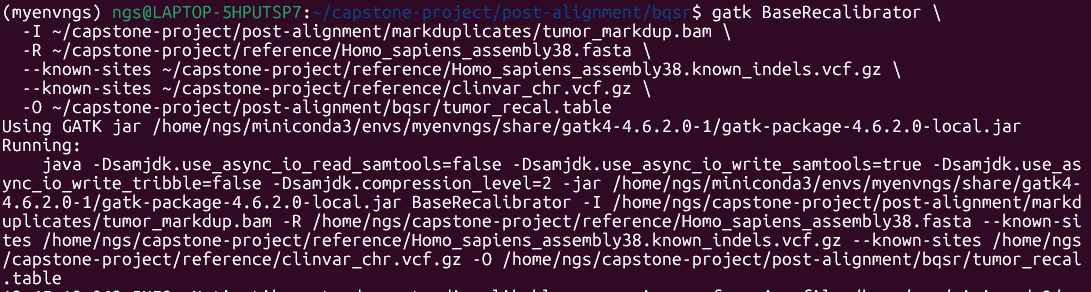

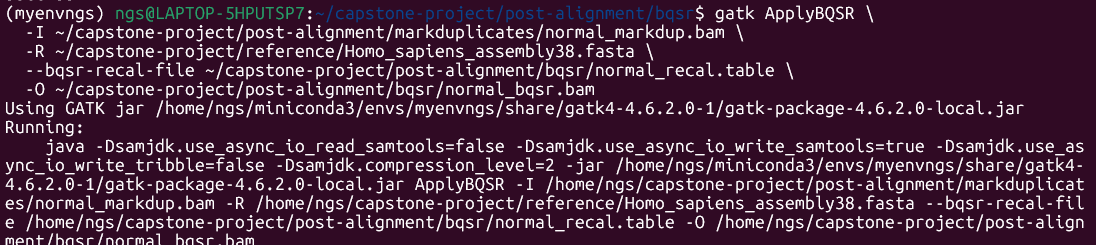

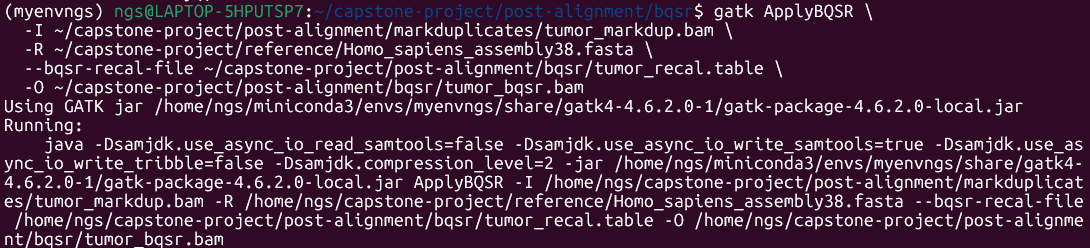

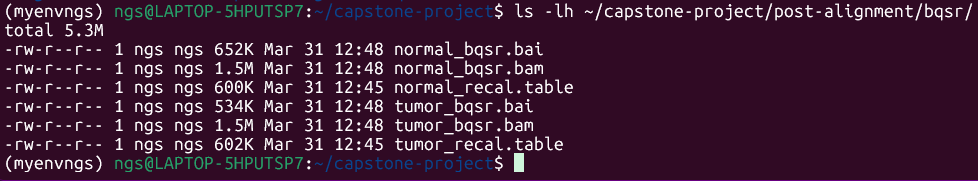

## Somatic Variant Calling

Setelah semua data pra-pemrosesan selesai, langkah kunci dalam analisis genomik kanker atau penyakit yang didapat adalah **Somatic Variant Calling**. Ini adalah proses mengidentifikasi variasi genetik (mutasi) yang hanya ada pada sel tumor (atau sel yang sakit) dan tidak ada pada sel normal dari individu yang sama.

Berbeda dengan *germline variant calling* yang mencari variasi genetik yang diwariskan dari orang tua dan ada di setiap sel tubuh, *somatic variant calling* fokus pada mutasi yang muncul *de novo* dalam sel somatik dan seringkali menjadi pendorong perkembangan penyakit seperti kanker.

**Mengapa Somatic Variant Calling penting?**

*   **Diagnosis Kanker:** Mengidentifikasi mutasi somatik dapat membantu dalam diagnosis jenis kanker tertentu.
*   **Prognosis:** Beberapa mutasi somatik memiliki implikasi prognostik, memprediksi bagaimana penyakit akan berkembang.
*   **Terapi Target:** Banyak terapi kanker modern dirancang untuk menargetkan mutasi somatik spesifik. Deteksi mutasi ini krusial untuk memilih pengobatan yang tepat.
*   **Pemahaman Mekanisme Penyakit:** Studi mutasi somatik memberikan wawasan tentang jalur genetik yang terlibat dalam inisiasi dan perkembangan penyakit.

**GATK Mutect2**

**Mutect2** adalah alat *variant caller* dari GATK (Genome Analysis Toolkit) yang dirancang khusus untuk mendeteksi mutasi somatik dengan sensitivitas tinggi. Mutect2 biasanya mengambil dua file BAM input: satu dari sampel tumor dan satu lagi dari sampel normal (kontrol) dari individu yang sama. Dengan membandingkan kedua sampel ini, Mutect2 dapat secara efektif menyaring varian *germline* yang ada di kedua sampel dan hanya melaporkan varian yang unik untuk sampel tumor.

**Penjelasan Perintah GATK Mutect2**

Perintah `gatk Mutect2` yang Anda berikan digunakan untuk melakukan *somatic variant calling*. Berikut adalah rincian dari setiap argumen:

```bash
gatk Mutect2 \
  -L chr1 \
  -L chr7 \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  -I ~/capstone-project/post-alignment/bqsr/tumor_bqsr.bam \
  -I ~/capstone-project/post-alignment/bqsr/normal_bqsr.bam \
  -tumor tumor \
  -normal normal \
  -O ~/capstone-project/variants/vcf/somatic.vcf
```

*   `gatk Mutect2`: Memanggil alat Mutect2 dari GATK.

*   `-L chr1 -L chr7`: Ini adalah opsi untuk menentukan interval atau wilayah genom spesifik yang akan dianalisis. Dalam kasus ini, Mutect2 akan hanya mencari mutasi somatik pada kromosom 1 dan kromosom 7. Penggunaan opsi `-L` beberapa kali memungkinkan spesifikasi beberapa wilayah.

*   `-R ~/capstone/reference/Homo_sapiens_assembly38.fasta`: Menentukan jalur ke file *reference genome* (`fasta`) yang digunakan untuk *alignment*. Ini sangat penting agar Mutect2 dapat memetakan *reads* dengan benar dan mengidentifikasi variasi relatif terhadap *reference genome*.

*   `-I ~/capstone-project/post-alignment/bqsr/tumor_bqsr.bam`: Menentukan jalur ke file BAM input untuk sampel **tumor**. File ini harus sudah di-*align*, diurutkan, dan idealnya sudah melalui proses *marking duplicates* dan BQSR.

*   `-I ~/capstone-project/post-alignment/bqsr/normal_bqsr.bam`: Menentukan jalur ke file BAM input untuk sampel **normal** (kontrol). Sama seperti sampel tumor, file ini juga harus sudah di-*align*, diurutkan, dan diproses sebelumnya.

*   `-tumor tumor`: Menentukan nama sampel tumor. Nama ini akan digunakan dalam file VCF output. Dalam contoh ini, nama sampel tumor diset sebagai `tum`.

*   `-normal normal`: Menentukan nama sampel normal. Nama ini juga akan digunakan dalam file VCF output. Dalam contoh ini, nama sampel normal diset sebagai `nor`.

*   `-O ~/capstone-project/variants/vcf/somatic.vcf`: Menentukan jalur dan nama file output VCF (`Variant Call Format`) yang akan berisi daftar mutasi somatik yang terdeteksi oleh Mutect2. File ini akan disimpan di direktori `~/capstone/outfile/` dengan nama `somatic.vcf`.

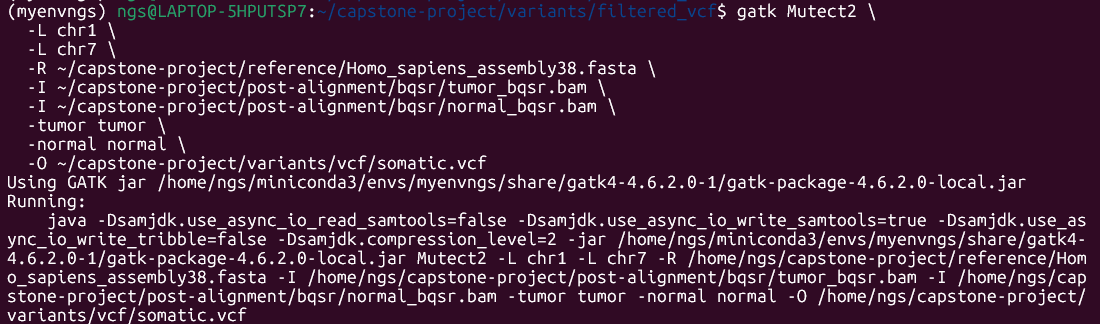

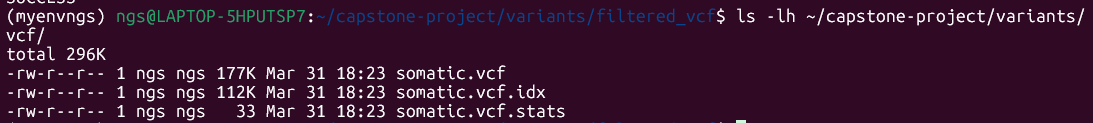

## Filter Somatic Variants

Setelah mutasi somatik diidentifikasi menggunakan alat seperti GATK Mutect2, langkah krusial berikutnya adalah **penyaringan atau filtering varian somatik**. Proses *variant calling* seringkali menghasilkan sejumlah besar kandidat varian, dan tidak semuanya adalah mutasi somatik yang *real* atau relevan secara biologis. Banyak di antaranya mungkin merupakan *false positives* yang disebabkan oleh kesalahan *sequencing*, *alignment artifacts*, *bias* dalam persiapan *library*, atau masalah lain dalam data.

**Mengapa Filter Somatic Variants penting?**

1.  **Mengurangi *False Positives*:** Alat *variant caller* seperti Mutect2 dirancang untuk sensitif, yang berarti mereka cenderung mendeteksi banyak kandidat varian, termasuk yang sebenarnya adalah *noise*. Proses *filtering* membantu menghilangkan varian-varian yang kemungkinan besar bukan mutasi somatik asli.
2.  **Meningkatkan Akurasi:** Dengan menyaring varian yang meragukan, kita dapat meningkatkan tingkat kepercayaan terhadap varian somatik yang tersisa, sehingga hasil analisis selanjutnya menjadi lebih akurat dan dapat diandalkan.
3.  **Prioritisasi Varian:** Analisis selanjutnya, seperti anotasi dan interpretasi klinis, akan jauh lebih efisien jika hanya fokus pada varian yang paling kuat dan kredibel.
4.  **Standarisasi Kualitas:** Proses *filtering* seringkali mengikuti pedoman tertentu (misalnya, dari GATK Best Practices) untuk memastikan kualitas varian yang konsisten.

**GATK FilterMutectCalls**

**FilterMutectCalls** adalah alat dari GATK yang dirancang khusus untuk menganalisis output dari Mutect2 dan menerapkan berbagai filter berdasarkan karakteristik varian. Alat ini memeriksa metrik-metrik yang dihasilkan oleh Mutect2 (seperti *allele frequencies*, *read depth*, *strand bias*, dll.) dan menandai varian yang tidak memenuhi ambang batas kualitas sebagai 'FILTERED' dalam file VCF. Varian yang melewati semua filter akan ditandai dengan 'PASS'.

**Penjelasan Perintah GATK FilterMutectCalls**

Perintah `gatk FilterMutectCalls` yang Anda berikan digunakan untuk menyaring varian somatik yang telah dipanggil oleh Mutect2. Berikut adalah rincian dari setiap argumen:

```bash
gatk FilterMutectCalls \
  -V ~/capstone-project/variants/vcf/somatic.vcf \
  -R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta \
  -O ~/capstone-project/variants/filtered_vcf/somatic_filtered.vcf
```

*   `gatk FilterMutectCalls`: Memanggil alat FilterMutectCalls dari GATK.

*   `-V ~/capstone-project/variants/vcf/somatic.vcf`: Menentukan jalur ke file VCF input yang berisi daftar varian somatik mentah yang dihasilkan oleh Mutect2. File ini akan dianalisis untuk menentukan status filter setiap varian.

*   `-R ~/capstone-project/reference/Homo_sapiens_assembly38.fasta`: Menentukan jalur ke file *reference genome* (`fasta`) yang sama yang digunakan selama proses *alignment* dan *variant calling*. Informasi ini diperlukan oleh FilterMutectCalls untuk konteks genomik saat menerapkan filter.

*   `-O ~/capstone-project/variants/filtered_vcf/somatic_filtered.vcf`: Menentukan jalur dan nama file output VCF baru. File ini akan berisi semua varian dari file input, tetapi dengan kolom `FILTER` yang diperbarui untuk menunjukkan apakah setiap varian 'PASS' (lolos filter) atau telah 'FILTERED' (gagal melewati satu atau lebih filter). File ini akan disimpan di direktori `~/capstone-project/variants/filtered_vcf/` dengan nama `somatic_filtered.vc`.

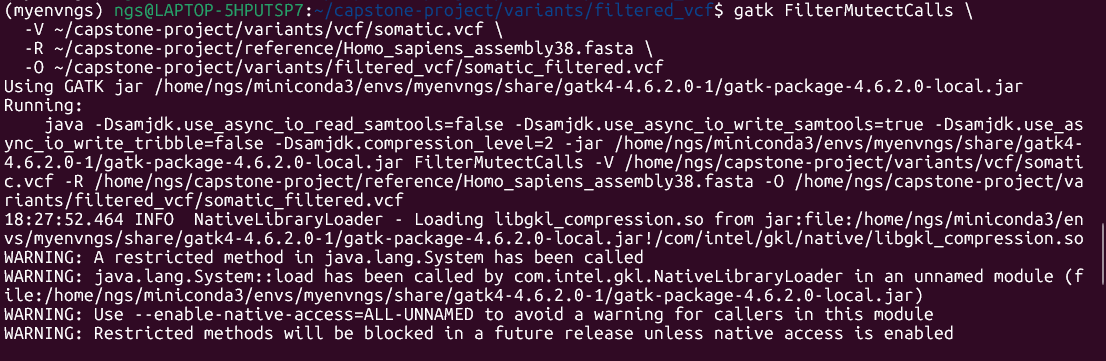

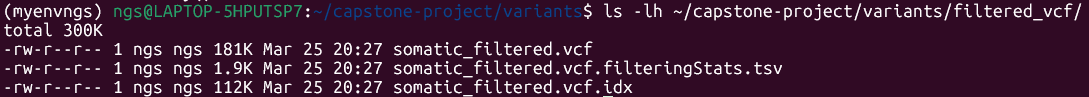

## Extract PASS Variants

Setelah proses *filtering* varian somatik menggunakan alat seperti GATK FilterMutectCalls, langkah selanjutnya yang sangat penting adalah mengekstraksi hanya varian yang telah melewati semua filter, yang ditandai dengan status `PASS`. Ini memastikan bahwa analisis *downstream* hanya dilakukan pada varian yang memiliki tingkat kepercayaan tinggi dan kemungkinan besar merupakan mutasi somatik yang asli.

**Mengapa mengekstrak varian `PASS` penting?**

1.  **Fokus pada Varian Berkualitas Tinggi:** File VCF hasil *filtering* biasanya masih mengandung semua varian, baik yang `PASS` maupun yang `FILTERED`. Dengan mengekstrak hanya varian `PASS`, kita membuat file VCF yang lebih kecil dan lebih bersih yang hanya berisi kandidat varian somatik yang paling kredibel.
2.  **Efisiensi Analisis Downstream:** Alat anotasi dan interpretasi *downstream* akan bekerja lebih cepat dan efisien karena mereka tidak perlu memproses atau mengabaikan varian yang sudah jelas tidak lolos filter.
3.  **Mengurangi Kesalahan Interpretasi:** Dengan hanya bekerja pada varian `PASS`, risiko untuk salah menginterpretasikan *false positives* sebagai mutasi biologis akan berkurang secara signifikan.

Alat yang umum digunakan untuk melakukan ekstraksi ini adalah **BCFtools**, yang merupakan *suite* program untuk memanipulasi file VCF dan BCF (Binary VCF).

**Penjelasan Perintah `bcftools view` dan `tabix`**

Berikut adalah rincian dari setiap perintah yang Anda berikan:

```bash
bcftools view -f PASS -o ~/capstone/outfile/somatic_pass_only.vcf.gz -O z ~/capstone/outfile/somatic_add-filterstatus.vcf
tabix -p vcf ~/capstone/outfile/somatic_pass_only.vcf.gz
```

**Perintah 1: `bcftools view`**

`bcftools view` digunakan untuk melihat, memfilter, dan mengkonversi file VCF/BCF. Berikut adalah penjelasannya:

*   `bcftools view`: Memanggil alat `view` dari BCFtools.

*   `-f PASS`: Ini adalah filter yang sangat penting. Opsi `-f` digunakan untuk memfilter berdasarkan kolom `FILTER`. Dengan `PASS`, perintah ini akan hanya memilih varian yang memiliki status `FILTER=PASS` di kolom `FILTER` VCF.

*   `-o ~/capstone/outfile/somatic_pass_only.vcf.gz`: Menentukan jalur dan nama file output. Varian yang lolos filter akan disimpan ke file ini. Penamaan `somatic_pass_only.vcf.gz` menunjukkan bahwa ini adalah file VCF yang hanya berisi varian `PASS`, dan `.gz` menunjukkan bahwa file ini akan dikompresi.

*   `-O z`: Menentukan format output. Opsi `z` berarti output akan dalam format VCF terkompresi dengan `bgzip` (`.vcf.gz`). Ini adalah format yang direkomendasikan untuk file VCF yang akan diindeks dan diproses lebih lanjut.

*   `~/capstone/outfile/somatic_add-filterstatus.vcf`: Menentukan jalur ke file VCF input yang berisi varian somatik yang telah difilter oleh GATK FilterMutectCalls (yaitu, file yang mengandung status `PASS` atau `FILTERED`).

**Perintah 2: `tabix`**

`tabix` digunakan untuk mengindeks file teks terkompresi, seperti VCF. Pengindeksan memungkinkan akses cepat ke data berdasarkan koordinat genomik. Berikut adalah penjelasannya:

*   `tabix`: Memanggil alat `tabix`.

*   `-p vcf`: Menentukan tipe file input sebagai VCF. Tabix juga dapat mengindeks format lain seperti GFF, BED, atau SAM.

*   `~/capstone/outfile/somatic_pass_only.vcf.gz`: Menentukan jalur ke file VCF terkompresi yang akan diindeks. Setelah perintah ini dijalankan, akan terbentuk file indeks baru dengan ekstensi `.tbi` (misalnya, `somatic_pass_only.vcf.gz.tbi`) di direktori yang sama.

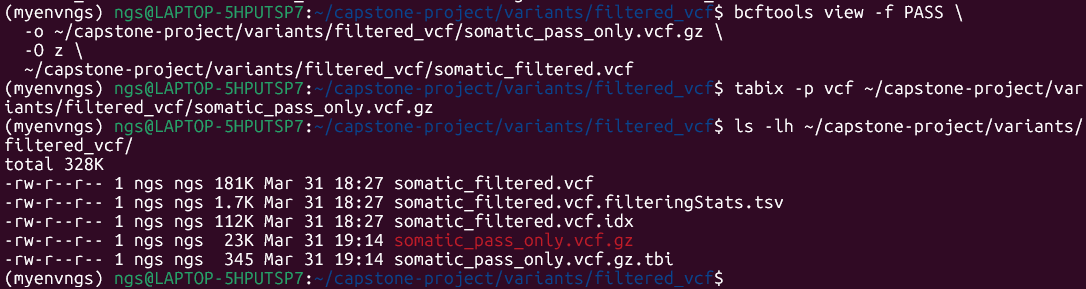

## Annotate Somatic Variants with ClinVar

Setelah mendapatkan daftar varian somatik berkualitas tinggi (`PASS`), langkah berikutnya yang sangat penting adalah **anotasi**. Anotasi adalah proses menambahkan informasi fungsional, klinis, atau biologi ke setiap varian. Dalam konteks analisis varian somatik, anotasi dengan basis data seperti **ClinVar** sangat krusial untuk memahami potensi dampak klinis dari mutasi yang terdeteksi.

**Mengapa Anotasi dengan ClinVar penting?**

1.  **Interpretasi Klinis:** ClinVar menyediakan informasi mengenai patogenisitas varian, fenotipe terkait, dan *clinical significance*. Ini membantu peneliti dan klinisi menginterpretasikan apakah mutasi somatik yang ditemukan memiliki relevansi klinis, misalnya terkait dengan respons terapi atau prognosis penyakit.
2.  **Prioritisasi Varian:** Dengan informasi dari ClinVar, varian dapat diprioritaskan. Mutasi yang sebelumnya telah diklasifikasikan sebagai patogenik atau *likely pathogenic* akan menjadi kandidat utama untuk penelitian lebih lanjut atau tindakan klinis.
3.  **Memperkaya Data:** Proses anotasi menambahkan kolom informasi baru ke file VCF Anda, membuat file tersebut lebih kaya data dan lebih mudah untuk dianalisis lebih lanjut.
4.  **Menghubungkan dengan Literatur:** Banyak entri di ClinVar memiliki referensi ke publikasi ilmiah, memungkinkan peneliti untuk dengan cepat mencari informasi lebih lanjut tentang varian tertentu.

**Alat Umum untuk Anotasi:**

**BCFtools** adalah salah satu alat yang sangat kuat dan fleksibel untuk memanipulasi dan menganotasi file VCF/BCF. Dengan `bcftools annotate`, Anda dapat menambahkan informasi dari satu file VCF (misalnya, ClinVar) ke file VCF Anda sendiri (varian somatik yang telah difilter).

**Penjelasan Perintah `bcftools annotate` dan `tabix`**

Berikut adalah rincian dari setiap perintah yang Anda berikan untuk menganotasi varian somatik dengan ClinVar:

```bash
bcftools annotate \
-a ~/capstone/reference/clinvar_chr.vcf.gz \
-c ID,INFO \
-h <(bcftools view -h ~/capstone/reference/clinvar_chr.vcf.gz | grep "^##INFO=") \
~/capstone/outfile/somatic_pass_only.vcf.gz \
-Oz -o ~/capstone/outfile/somatic-annotate.vcf.gz

tabix -p vcf ~/capstone/outfile/somatic-annotate.vcf.gz
```

**Perintah 1: `bcftools annotate`**

`bcftools annotate` digunakan untuk menambahkan atau menghapus informasi dari file VCF/BCF. Berikut adalah penjelasannya:

*   `bcftools annotate`: Memanggil alat `annotate` dari BCFtools.

*   `-a ~/capstone/reference/clinvar_chr.vcf.gz`: Menentukan file VCF anotasi (dalam hal ini, file ClinVar yang sudah disiapkan) yang akan digunakan sebagai sumber informasi. File ini harus sudah diindeks (`.tbi`).

*   `-c ID,INFO`: Menentukan kolom-kolom dari file anotasi (`-a`) yang akan ditambahkan ke file VCF input. Dalam contoh ini, kolom `ID` (identifier varian, seperti rsID atau ClinVar ID) dan kolom `INFO` (yang berisi berbagai metadata, termasuk *clinical significance*) akan diambil dari ClinVar.

*   `-h <(bcftools view -h ~/capstone/reference/clinvar_chr.vcf.gz | grep "^##INFO=")`: Ini adalah bagian yang sedikit lebih kompleks. Opsi `-h` memungkinkan penambahan *header lines* kustom. Sub-perintah `bcftools view -h ~/capstone/reference/clinvar_chr.vcf.gz | grep "^##INFO="` akan mengekstrak semua baris *header* yang dimulai dengan `##INFO=` dari file ClinVar. Ini diperlukan agar definisi bidang `INFO` yang ditambahkan dari ClinVar juga termasuk dalam *header* file output, sehingga alat *downstream* dapat memahami kolom `INFO` yang baru.

*   `~/capstone/outfile/somatic_pass_only.vcf.gz`: Menentukan file VCF input yang akan dianotasi. Ini adalah file varian somatik yang telah difilter dan hanya berisi varian `PASS`.

*   `-Oz -o ~/capstone/outfile/somatic-annotate.vcf.gz`: Mirip dengan `bcftools view`, ini menentukan format output (`-Oz` untuk VCF terkompresi dengan `bgzip`) dan nama file output (`-o` diikuti dengan jalur dan nama file). File output ini akan berisi varian somatik `PASS` Anda dengan tambahan informasi anotasi dari ClinVar.

**Perintah 2: `tabix`**

`tabix` digunakan untuk mengindeks file VCF yang telah dianotasi, sehingga memungkinkan akses cepat dan efisien ke data berdasarkan koordinat genomik untuk analisis atau visualisasi selanjutnya.

*   `tabix -p vcf ~/capstone/outfile/somatic-annotate.vcf.gz`: Mengindeks file VCF terkompresi yang baru saja dibuat. Ini akan menghasilkan file indeks (`.tbi`) di direktori yang sama.

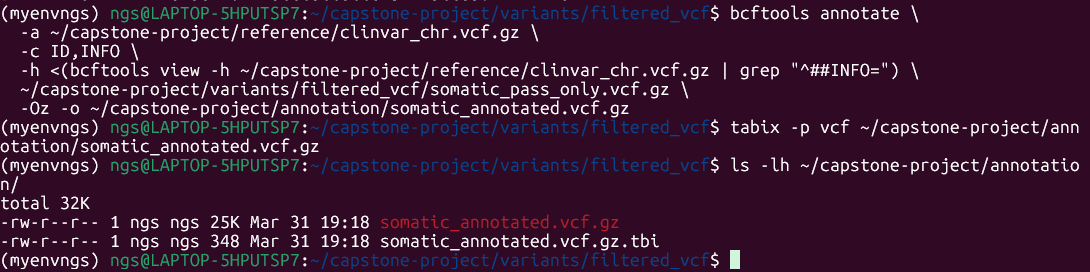

## Extract and Tidy Up Annotation Results

Setelah melakukan anotasi varian somatik dengan ClinVar, langkah selanjutnya adalah mengekstrak informasi yang relevan dari file VCF yang telah dianotasi (`somatic-annotate.vcf.gz`) dan menyajikannya dalam format yang lebih rapi serta mudah dianalisis, yaitu file CSV. File VCF, meskipun kaya data, seringkali sulit dibaca dan diolah secara langsung untuk analisis hilir atau visualisasi.

Proses ini bertujuan untuk:
1.  **Ekstraksi Data Terseleksi:** Mengambil hanya kolom-kolom spesifik yang dibutuhkan (misalnya, informasi varian umum, signifikansi klinis dari ClinVar, dan detail spesifik untuk sampel normal dan tumor).
2.  **Perapian Format:** Mengubah format dari VCF yang kompleks menjadi format tabel (TSV sementara, kemudian CSV final) yang lebih standar dan kompatibel dengan alat analisis data seperti pandas atau spreadsheet.
3.  **Pengorganisasian Data:** Menggabungkan baris-baris data terkait (varian dan informasi sampel normal/tumor) menjadi satu baris logis untuk setiap varian.

### Penjelasan Kode
Kode ini terbagi menjadi dua bagian utama: perintah `bcftools query` dan skrip Python.

#### Perintah `bcftools query`
`bcftools query` adalah alat yang sangat berguna untuk mengekstrak data dari file VCF/BCF ke dalam format teks yang dapat dibaca manusia (biasanya TSV). Ini memungkinkan kita memilih kolom-kolom tertentu dan format output sesuai kebutuhan.

```bash
bcftools query \
  -s normal,tumor \
  -f '%CHROM\t%POS\t%ID\t%REF\t%ALT\t%FILTER\t%GENEINFO\t%CLNSIG\t%CLNDN\t%MC\t%ONC\t%SCI\n[%SAMPLE\t%GT\t%AD\t%AF\t%DP\t%F1R2\t%F2R1\t%FAD\t%SB\n]' \
  ~/capstone/outfile/somatic-annotate.vcf.gz \
  > ~/capstone/outfile/somatic_annotated_full_clean.tsv
```

*   `bcftools query`: Memanggil alat query dari BCFtools.
*   `-s normal,tumor`: Menentukan sampel yang ingin diekstrak datanya. Dalam kasus ini, kita tertarik pada data dari sampel 'normal' dan 'tumor'.
*   `-f '...'`: Ini adalah bagian terpenting yang mendefinisikan format output:
    *   `%CHROM\t%POS\t%ID\t%REF\t%ALT\t%FILTER`: Mengekstrak kolom-kolom standar VCF seperti kromosom, posisi, ID varian, alel referensi dan alternatif, serta informasi FILTER.
    *   `%GENEINFO\t%CLNSIG\t%CLNDN\t%MC\t%ONC\t%SCI`: Mengekstrak informasi anotasi tambahan yang seharusnya telah ditambahkan dari ClinVar ke dalam kolom INFO. Contohnya:
        *   `GENEINFO`: Informasi gen terkait.
        *   `CLNSIG`: Clinical Significance (dari ClinVar).
        *   `CLNDN`: Clinical Disease Name (dari ClinVar).
        *   `MC`: Consequence (dampak pada protein).
        *   `ONC`: Oncotree code (jika relevan).
        *   `SCI`: Scientific references (misalnya, PMID).
    *   `\n`: Menambahkan baris baru setelah informasi varian umum (kolom-kolom di atas).
    *   `[%SAMPLE\t%GT\t%AD\t%AF\t%DP\t%F1R2\t%F2R1\t%FAD\t%SB\n]`: Bagian dalam kurung siku `[]` ini diulang untuk setiap sampel yang ditentukan dengan `-s`. Ini mengekstrak informasi spesifik sampel:
        *   `%SAMPLE`: Nama sampel (normal atau tumor).
        *   `%GT`: Genotipe.
        *   `%AD`: Depth of coverage untuk alel referensi dan alternatif.
        *   `%AF`: Allele Frequency.
        *   `%DP`: Read Depth.
        *   `%F1R2`, `%F2R1`, `%FAD`, `%SB`: Metrik lain yang terkait dengan kualitas pembacaan dan *strand bias*.
    *   Setiap `\t` adalah karakter tabulasi, untuk memisahkan kolom.
*   `~/capstone/outfile/somatic-annotate.vcf.gz`: Ini adalah file input VCF yang telah dianotasi.
*   `> ~/capstone/outfile/somatic_annotated_full_clean.tsv`: Mengarahkan output dari `bcftools query` ke file teks berekstensi `.tsv` (Tab-Separated Values).

#### Skrip Python
Skrip Python ini berfungsi untuk membaca file TSV yang dihasilkan oleh `bcftools query` dan menyusun ulang datanya ke dalam format CSV yang lebih rapi, di mana setiap varian memiliki satu baris data lengkap termasuk informasi normal dan tumor.

```python
import csv

# Mendefinisikan header untuk file CSV akhir
header = ["CHROM","POS","ID","REF","ALT","FILTER","GENE","CLNSIG","CLNDN","MC","ONC","SCI",
          "GT_NORMAL","AD_NORMAL","AF_NORMAL","DP_NORMAL","F1R2_NORMAL","F2R1_NORMAL","FAD_NORMAL","SB_NORMAL",
          "GT_TUMOR","AD_TUMOR","AF_TUMOR","DP_TUMOR","F1R2_TUMOR","F2R1_TUMOR","FAD_TUMOR","SB_TUMOR"]

rows = []
with open('/home/ngs/capstone/outfile/somatic_annotated_full_clean.tsv') as f:
    lines = [l.strip() for l in f if l.strip()] # Membaca setiap baris dan menghapus spasi di awal/akhir

i = 0
while i < len(lines):
    variant = lines[i].split('\t') # Baris pertama adalah informasi varian umum
    
    # Baris kedua adalah informasi sampel normal. Mengambil data mulai dari indeks ke-1 (setelah nama sampel).
    # Penanganan jika baris tidak ada (misalnya, file berakhir lebih awal, meskipun tidak mungkin dalam skenario ini)
    normal  = lines[i+1].split('\t')[1:] if i+1 < len(lines) else []
    
    # Baris ketiga adalah informasi sampel tumor, juga dimulai dari indeks ke-1.
    tumor   = lines[i+2].split('\t')[1:] if i+2 < len(lines) else []
    
    # Menggabungkan semua informasi ke dalam satu daftar (varian + normal + tumor)
    rows.append(variant + normal + tumor)
    
    i += 3 # Melompat 3 baris untuk varian berikutnya

with open('~/capstone/outfile/somatic_clean_final.csv', 'w', newline='') as fout:
    writer = csv.writer(fout, quoting=csv.QUOTE_ALL) # Membuat objek writer CSV
    writer.writerow(header) # Menulis baris header
    writer.writerows(rows) # Menulis semua baris data

print(f"Done! {len(rows)} variants written to somatic_clean_final.csv") # Mencetak konfirmasi
```

**Cara Kerja Skrip Python:**
1.  **Membaca TSV:** Skrip membuka file `somatic_annotated_full_clean.tsv` dan membaca semua barisnya.
2.  **Iterasi Per Varian:** Karena `bcftools query` menghasilkan 3 baris per varian (1 baris varian umum, 1 baris sampel normal, 1 baris sampel tumor), skrip mengiterasi file dengan melompat 3 baris setiap kali.
3.  **Parsing Baris:** Setiap baris dipecah berdasarkan karakter tab (`\t`) menjadi daftar elemen.
    *   `variant = lines[i].split('\t')` mengambil data umum varian.
    *   `normal = lines[i+1].split('\t')[1:]` mengambil data spesifik sampel normal, menghilangkan elemen pertama karena itu adalah nama sampel ('normal') yang sudah kita ketahui.
    *   `tumor = lines[i+2].split('\t')[1:]` melakukan hal yang sama untuk sampel tumor.
4.  **Menggabungkan Data:** Daftar `variant`, `normal`, dan `tumor` digabungkan menjadi satu daftar tunggal, yang merepresentasikan satu baris untuk satu varian di output CSV.
5.  **Menulis CSV:** Menggunakan modul `csv`, skrip menulis header yang telah ditentukan dan kemudian semua baris data yang telah dirakit ke dalam file `somatic_clean_final.csv`.